# Text Analytics Coursework

This notebook provides some example code for loading and examining the dataset for task 3. 

In [2]:
%load_ext autoreload
%autoreload 2


# Use HuggingFace's datasets library to access the Emotion dataset
from datasets import load_dataset
import numpy as np
import pandas as pd 

# Task 3 - arXiv abstracts

This dataset contains arXiv abstracts over a many year. Let's first load it and examine the fields:

In [3]:
from datasets import load_dataset

# Load the arXiv abstracts dataset
# dataset = load_dataset("gfissore/arxiv-abstracts-2021", split="train")
dataset= load_dataset(
    "gfissore/arxiv-abstracts-2021",
    cache_dir="E:/ds课程ppt/AI/week56 code/slh_courswork/huggingface",
    split="train"
)
print(dataset[0])

{'id': '0704.0001', 'submitter': 'Pavel Nadolsky', 'authors': "C. Bal\\'azs, E. L. Berger, P. M. Nadolsky, C.-P. Yuan", 'title': 'Calculation of prompt diphoton production cross sections at Tevatron and\n  LHC energies', 'comments': '37 pages, 15 figures; published version', 'journal-ref': 'Phys.Rev.D76:013009,2007', 'doi': '10.1103/PhysRevD.76.013009', 'abstract': '  A fully differential calculation in perturbative quantum chromodynamics is\npresented for the production of massive photon pairs at hadron colliders. All\nnext-to-leading order perturbative contributions from quark-antiquark,\ngluon-(anti)quark, and gluon-gluon subprocesses are included, as well as\nall-orders resummation of initial-state gluon radiation valid at\nnext-to-next-to-leading logarithmic accuracy. The region of phase space is\nspecified in which the calculation is most reliable. Good agreement is\ndemonstrated with data from the Fermilab Tevatron, and predictions are made for\nmore detailed tests with CDF and 

C:\Users\18730\.conda\envs\text_analytics\Lib\site-packages\datasets\table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


We can now filter it to get abstracts about a particular topic or field:

In [4]:

# filter by category
field = "cs.LG"  # Focus on Machine Learning
def filter_category(example):
    return field in example['categories']

filtered = dataset.filter(filter_category)

# Remove missing/short abstracts
def valid_abstract(example):
    return example['abstract'] is not None and len(example['abstract']) > 50

filtered = filtered.filter(valid_abstract)

Another useful step is to get the date of each abstract, e.g., for plotting trends. This is not stored in the dataset object, but we can infer it from the ID. 

In [5]:
# -----------------------
# Infer year from arXiv ID
# -----------------------
def extract_year(arxiv_id):
    if arxiv_id.startswith("cs/"):
        arxiv_id = arxiv_id.split("/")[1]
    yy = int(arxiv_id[:2])
    return 1900 + yy if yy >= 91 else 2000 + yy

years = [extract_year(x) for x in filtered["id"]]

# -----------------------
# Prepare docs
# -----------------------
docs = filtered['abstract']

In [6]:
import pandas as pd

df = pd.DataFrame({
    "id": filtered["id"],
    "categories": filtered["categories"],
    "year": years,
    "field": [field] * len(filtered),#all the same
    "abstract": filtered["abstract"]
})

pd.set_option('display.max_colwidth', None)  # 不限制列宽 
pd.set_option('display.max_rows', None)     # 不限制行数
print(df["abstract"].head(1))
print(df.shape)

0      This paper uncovers and explores the close relationship between Monte Carlo\nOptimization of a parametrized integral (MCO), Parametric machine-Learning\n(PL), and `blackbox' or `oracle'-based optimization (BO). We make four\ncontributions. First, we prove that MCO is mathematically identical to a broad\nclass of PL problems. This identity potentially provides a new application\ndomain for all broadly applicable PL techniques: MCO. Second, we introduce\nimmediate sampling, a new version of the Probability Collectives (PC) algorithm\nfor blackbox optimization. Immediate sampling transforms the original BO\nproblem into an MCO problem. Accordingly, by combining these first two\ncontributions, we can apply all PL techniques to BO. In our third contribution\nwe validate this way of improving BO by demonstrating that cross-validation and\nbagging improve immediate sampling. Finally, conventional MC and MCO procedures\nignore the relationship between the sample point locations and the 

In [7]:
# This code performs text preprocessing to prepare the corpus for later analysis in Task 3.
# It defines two different preprocessing pipelines:
# 1. preprocess_for_tfidf_lda(): stronger preprocessing for TF-IDF and LDA
#    - lowercase conversion
#    - newline removal
#    - removal of non-letter characters
#    - tokenization
#    - stopword removal
#    - lemmatization
#    - removal of very short words
#
# 2. preprocess_for_embedding(): lighter preprocessing for embedding-based methods
#    - preserves the original sentence structure
#    - only removes extra newlines and spaces
#
# In Task 3, this step is important because it:
# - creates clean token-based input for TF-IDF and LDA
# - preserves richer semantic information for embedding-based models such as BERTopic
# - ensures that each method receives the most suitable text representation for fair comparison


import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# need to download for the first time 
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


# 1) preprocessing for TF-IDF / LDA 
# 给 TF-IDF / LDA 用的预处理


def preprocess_for_tfidf_lda(text, stop_words_set=None):
    if pd.isna(text):
        return []

    if stop_words_set is None:
        stop_words_set = set()

    text = text.lower()
    text = text.replace("\n", " ")
    text = re.sub(r"[^a-z\s]", " ", text)

    tokens = word_tokenize(text)

    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words_set and len(token) > 2
    ]

    return tokens


# 2)  preprocessing for embedding
# 给 embedding 用的轻预处理
# -----------------------
def preprocess_for_embedding(text):
    if pd.isna(text):
        return ""
    
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text
# apply to df

df["tokens"] = df["abstract"].apply(preprocess_for_tfidf_lda)
df["clean_text_tfidf_lda"] = df["tokens"].apply(lambda x: " ".join(x))
df["clean_text_embed"] = df["abstract"].apply(preprocess_for_embedding)

print(df[["abstract", "tokens", "clean_text_tfidf_lda", "clean_text_embed"]].head(1))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\18730\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\18730\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\18730\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\18730\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [8]:
# This section prepares for temporal analysis by grouping documents into different time periods.
#
# Steps include:
# 1. Inspecting the year range and distribution of documents per year
# 2. Defining assign_period() to map years into predefined periods
# 3. Creating a new column df["period"]
# 4. Checking for any unassigned "other" category
# 5. (Optional) Removing documents outside the target periods
#
# In Task 3, this step:
# - divides the dataset into time segments
# - enables topic evolution and comparison across periods
# - forms the basis for temporal topic analysis
print(df["year"].min(), df["year"].max())
# print(df["year"].value_counts().sort_index().head(20))
print(df["year"].value_counts().sort_index())

1999 2021
year
1999       2
2000       6
2001       2
2002       2
2003       3
2004       2
2005      15
2006      19
2007      19
2008      32
2009      48
2010      94
2011      87
2012     111
2013     198
2014     234
2015     398
2016     461
2017     629
2018     194
2019     114
2020     806
2021    3539
Name: count, dtype: int64


In [9]:
def assign_period(year):
    if 1999 <= year <= 2010:
        return "1999-2010"
    elif 2011 <= year <= 2015:
        return "2011-2015"
    else:
        return "2016-2021"
    

df["period"] = df["year"].apply(assign_period)
# other_count = (df["period"] == "other").sum()
# 
# df = df[df["period"] != "other"].copy()
print(df["period"].value_counts())

# After splitting into periods, we observe a highly imbalanced distribution:
# - 1999–2010: 244 documents (early stage)
# - 2011–2015: 1028 documents (growth stage)
# - 2016–2021: 5743 documents (boom stage)
#
# This segmentation is reasonable because:
# 1. The dataset shows strong temporal growth, especially after 2016
# 2. Each period corresponds to a meaningful development stage
# 3. It avoids arbitrary equal splits that lack semantic meaning
#
# In Task 3, this supports:
# - analysing topic evolution over time
# - comparing topic distributions across periods
# - interpreting the development of the research field

period
2016-2021    5743
2011-2015    1028
1999-2010     244
Name: count, dtype: int64


In [10]:
df["clean_text_tfidf_lda"].head(10)


0    this paper uncovers and explores the close relationship between monte carlo optimization parametrized integral mco parametric machine learning and blackbox oracle based optimization make four contribution first prove that mco mathematically identical broad class problem this identity potentially provides new application domain for all broadly applicable technique mco second introduce immediate sampling new version the probability collective algorithm for blackbox optimization immediate sampling transforms the original problem into mco problem accordingly combining these first two contribution can apply all technique our third contribution validate this way improving demonstrating that cross validation and bagging improve immediate sampling finally conventional and mco procedure ignore the relationship between the sample point location and the associated value the integrand only the value the integrand those location are considered demonstrate that one can exploit the sample locati

In [11]:
#TF-IDF
# This section converts the preprocessed text into numerical TF-IDF features.
# The main steps are:
# 1. Inspecting cleaned text samples
# 2. Defining English stopwords and custom domain stopwords
# 3. Using TfidfVectorizer to transform text into a TF-IDF matrix
# 4. Limiting vocabulary size and filtering overly common or overly rare words
# 5. Converting the result into a DataFrame and attaching period labels
#
# In Task 3, this step is used to:
# - extract important terms from each document
# - build lexical representations for each period
# - support comparisons of distinctive words across time periods
# - help analyse how research themes change over time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text
import pandas as pd
# sklearn stopwords 自带英文停用词
english_stopwords = text.ENGLISH_STOP_WORDS

# custom_stopwords 自定义的领域停用词
custom_stopwords = {
    "learning", "method", "model", "data",
    "algorithm", "approach", "problem",
    "paper", "result", "using", "based",
    "real", "world", "state", "art",
}

# transform to list
all_stopwords = list(english_stopwords.union(custom_stopwords))
# all text所有文本
texts = df["clean_text_tfidf_lda"].tolist()
#can do parameter changing test here
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=all_stopwords,
    max_df=0.5,
    min_df=5
)

X = vectorizer.fit_transform(texts)
print(X[:10])
print(X.shape)
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

tfidf_df["period"] = df["period"].values

# print(tfidf_df.head())


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 387 stored elements and shape (10, 5000)>
  Coords	Values
  (0, 4744)	0.1261662206061957
  (0, 1725)	0.10106770549676679
  (0, 712)	0.08551621643376885
  (0, 3787)	0.14536938724462953
  (0, 2953)	0.10010765179821342
  (0, 589)	0.10010765179821342
  (0, 3153)	0.15289914030985735
  (0, 3237)	0.11658757350800189
  (0, 2425)	0.10885118349309438
  (0, 3235)	0.08887743439605075
  (0, 2728)	0.041798048453408336
  (0, 490)	0.24959234393094312
  (0, 3162)	0.09751365244504435
  (0, 2746)	0.055872863193609415
  (0, 963)	0.2293714944858767
  (0, 3564)	0.065723675597706
  (0, 2797)	0.10513580530319756
  (0, 2208)	0.10173902567452796
  (0, 532)	0.09390952679656514
  (0, 687)	0.05280703474586024
  (0, 2217)	0.1068928820978548
  (0, 3409)	0.08661204468754649
  (0, 3570)	0.12364190720779522
  (0, 3041)	0.08550549181733122
  (0, 248)	0.045402174101887564
  :	:
  (8, 858)	0.25396908067608187
  (8, 3231)	0.12347456767236377
  (8, 1729)	0.213566

In [12]:
# Compute the mean TF-IDF for each period,
# then extract the top words with highest average weights per period.
#
# Purpose:
# - identify representative keywords for each period
# - support analysis of topic evolution over time
#The results show:
# - 1999–2010: focus on theoretical methods (function, bound, kernel, classifier)
# - 2011–2015: more tasks and techniques emerge (feature, classification, clustering)
# - 2016–2021: strong shift to deep learning (network, neural, deep, training)
#
# This indicates a transition from theoretical foundations to deep learning-driven research.
mean_tfidf = tfidf_df.groupby("period").mean()

for period in mean_tfidf.index:
    print(f"\n===== {period} =====")
    print(mean_tfidf.loc[period].sort_values(ascending=False).head(10))


===== 1999-2010 =====
function        0.029909
bound           0.027854
class           0.023062
loss            0.022649
prediction      0.022435
kernel          0.021993
set             0.021707
distribution    0.020712
expert          0.019774
classifier      0.018210
Name: 1999-2010, dtype: float64

===== 2011-2015 =====
feature           0.027791
function          0.026663
classification    0.022334
kernel            0.022111
class             0.021411
classifier        0.020641
clustering        0.020492
set               0.020413
bound             0.019068
online            0.018502
Name: 2011-2015, dtype: float64

===== 2016-2021 =====
network        0.034072
graph          0.026262
neural         0.023833
training       0.023567
task           0.022078
time           0.020680
feature        0.020510
deep           0.020356
performance    0.020015
prediction     0.016581
Name: 2016-2021, dtype: float64


In [13]:
# English:
# Use TF-IDF with n-grams (2-3 word phrases)
# to capture more specific terms (e.g., "neural network").
# Then compute mean TF-IDF per period and extract top phrases.
#
# Purpose:
# - provide more precise topic signals than single words
# - track key methods/techniques across time periods
# The results show clear methodological evolution:
# - 1999–2010: traditional methods (support vector machine, decision tree)
# - 2011–2015: more diverse techniques (feature selection, semi-supervised, neural network emerging)
# - 2016–2021: dominated by deep learning (deep neural network, graph neural network)
#
# Compared to unigram results, n-grams provide clearer insight into specific models and techniques.
ngram_vectorizer = TfidfVectorizer(
    max_features=12000,
    stop_words=all_stopwords,
    max_df=0.5,
    min_df=3,
    ngram_range=(2,3)
)

ngram_X = ngram_vectorizer.fit_transform(texts)

ngram_tfidf_df = pd.DataFrame(
    ngram_X.toarray(),
    columns=ngram_vectorizer.get_feature_names_out()
)

ngram_tfidf_df["period"] = df["period"].values

ngram_mean_tfidf = ngram_tfidf_df.groupby("period").mean()

for period in ngram_mean_tfidf.index:
    print(f"\n===== {period} =====")
    print(ngram_mean_tfidf.loc[period].sort_values(ascending=False).head(10))


===== 1999-2010 =====
defensive forecasting       0.013306
support vector machine      0.010758
loss function               0.010747
support vector              0.010744
vector machine              0.010726
expert advice               0.010307
decision tree               0.009582
probability distribution    0.009468
prediction strategy         0.009279
latent variable             0.009186
Name: 1999-2010, dtype: float64

===== 2011-2015 =====
feature selection         0.011722
loss function             0.010040
support vector            0.009274
large scale               0.008945
neural network            0.008426
semi supervised           0.008239
time series               0.007436
gradient descent          0.007405
vector machine            0.007303
support vector machine    0.007194
Name: 2011-2015, dtype: float64

===== 2016-2021 =====
neural network          0.029763
time series             0.012237
deep neural             0.009450
deep neural network     0.009211
propose novel  

In [14]:
# Compute distinctive terms for each period:
# mean TF-IDF (current period) - mean TF-IDF (other periods)
# Higher values indicate terms that are more unique to that period.
#
# Purpose:
# - identify period-specific keywords
# - better capture differences than raw TF-IDF rankings
# The results highlight different research focuses:
# - 1999–2010: statistical and theoretical methods (exponential family, conjugate prior)
# - 2011–2015: optimisation and learning techniques (stochastic gradient, feature selection)
# - 2016–2021: deep learning and its variants (neural network, graph neural network, CNN)
#
# This shows a shift from statistical modelling to deep learning-driven research.
print("\n=== DISTINCTIVE TERMS BY PERIOD ===")

for period in ngram_mean_tfidf.index:
    current = ngram_mean_tfidf.loc[period]
    others = ngram_mean_tfidf.drop(period).mean()
    
    diff = current - others
    
    print(f"\n===== DISTINCTIVE {period} =====")
    print(diff.sort_values(ascending=False).head(10))


=== DISTINCTIVE TERMS BY PERIOD ===

===== DISTINCTIVE 1999-2010 =====
defensive forecasting       0.013306
expert advice               0.009526
prediction strategy         0.008959
exponential family          0.008043
prediction expert           0.007824
association rule            0.007422
probability distribution    0.007349
prediction expert advice    0.006871
conjugate prior             0.006847
true distribution           0.006652
dtype: float64

===== DISTINCTIVE 2011-2015 =====
feature selection              0.007155
large scale                    0.005600
stochastic gradient            0.004390
low dimensional                0.004036
boltzmann machine              0.003850
cost sensitive                 0.003513
semi supervised                0.003458
stochastic gradient descent    0.003358
objective function             0.003318
regret bound                   0.003302
dtype: float64

===== DISTINCTIVE 2016-2021 =====
neural network                  0.023852
deep neural      


=== TF-IDF COSINE SIMILARITY BETWEEN PERIODS ===
period     1999-2010  2011-2015  2016-2021
period                                    
1999-2010   1.000000   0.493377   0.332743
2011-2015   0.493377   1.000000   0.635560
2016-2021   0.332743   0.635560   1.000000

=== TF-IDF COSINE DISTANCE BETWEEN PERIODS ===
period        1999-2010     2011-2015     2016-2021
period                                             
1999-2010  5.551115e-16  5.066227e-01  6.672567e-01
2011-2015  5.066227e-01  1.221245e-15  3.644395e-01
2016-2021  6.672567e-01  3.644395e-01 -6.661338e-16


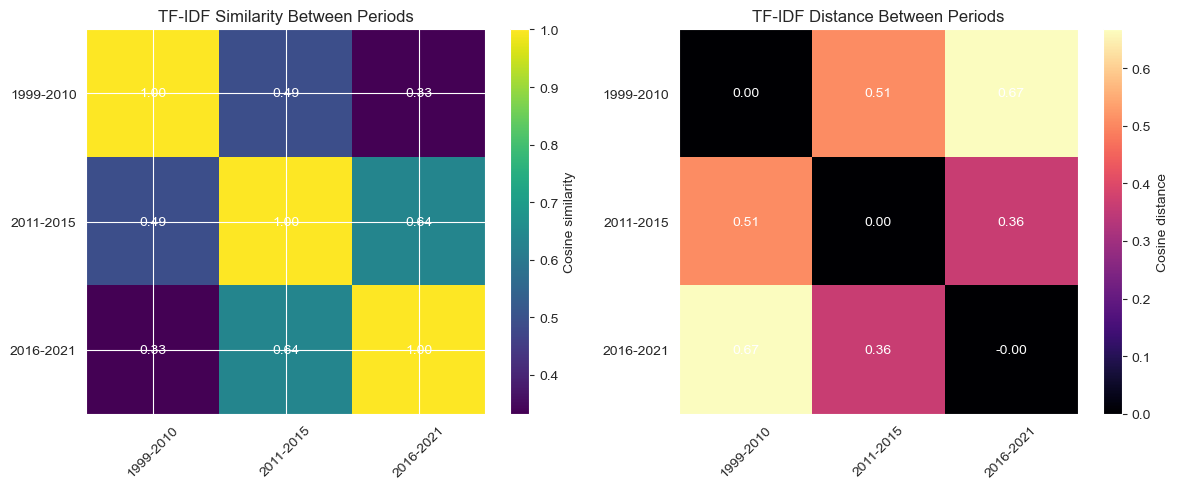

In [15]:
# from sklearn.metrics.pairwise import cosine_similarity
# 
# # calculate cosine similarity between different period


# Compute cosine similarity and cosine distance between periods
# based on their mean TF-IDF representations.
# Higher similarity means the periods are more similar in vocabulary use;
# larger distance means they are more different.
#
# The results are then stored as matrices and visualised as heatmaps

#The results show:
# - 2011–2015 and 2016–2021 are the most similar (similarity = 0.64)
# - 1999–2010 and 2016–2021 are the most different (distance = 0.67)
# - 1999–2010 and 2011–2015 are moderately related
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt

# 计算 TF-IDF 的 similarity 和 distance
similarity_matrix = cosine_similarity(ngram_mean_tfidf)
distance_matrix = 1 - similarity_matrix

# 转成 DataFrame
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=ngram_mean_tfidf.index,
    columns=ngram_mean_tfidf.index
)

distance_df = pd.DataFrame(
    distance_matrix,
    index=ngram_mean_tfidf.index,
    columns=ngram_mean_tfidf.index
)

print("\n=== TF-IDF COSINE SIMILARITY BETWEEN PERIODS ===")
print(similarity_df)

print("\n=== TF-IDF COSINE DISTANCE BETWEEN PERIODS ===")
print(distance_df)

#painting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---------- (1) Similarity ----------
ax1 = axes[0]
im1 = ax1.imshow(similarity_df, aspect="auto", cmap="viridis")
fig.colorbar(im1, ax=ax1, label="Cosine similarity")

ax1.set_xticks(range(len(similarity_df.columns)))
ax1.set_yticks(range(len(similarity_df.index)))
ax1.set_xticklabels(similarity_df.columns, rotation=45)
ax1.set_yticklabels(similarity_df.index)
ax1.set_title("TF-IDF Similarity Between Periods")

for i in range(len(similarity_df.index)):
    for j in range(len(similarity_df.columns)):
        ax1.text(j, i, f"{similarity_df.iloc[i, j]:.2f}",
                 ha="center", va="center", color="white")

# ---------- (2) Distance ----------
ax2 = axes[1]
im2 = ax2.imshow(distance_df, aspect="auto", cmap="magma")
fig.colorbar(im2, ax=ax2, label="Cosine distance")

ax2.set_xticks(range(len(distance_df.columns)))
ax2.set_yticks(range(len(distance_df.index)))
ax2.set_xticklabels(distance_df.columns, rotation=45)
ax2.set_yticklabels(distance_df.index)
ax2.set_title("TF-IDF Distance Between Periods")

for i in range(len(distance_df.index)):
    for j in range(len(distance_df.columns)):
        ax2.text(j, i, f"{distance_df.iloc[i, j]:.2f}",
                 ha="center", va="center", color="white")
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# 
# # ===== 1. 计算 TF-IDF 的 similarity 和 distance =====
# similarity_matrix = cosine_similarity(ngram_mean_tfidf)
# distance_matrix = 1 - similarity_matrix
# 
# # 转成 DataFrame
# similarity_df = pd.DataFrame(
#     similarity_matrix,
#     index=ngram_mean_tfidf.index,
#     columns=ngram_mean_tfidf.index
# )
# 
# distance_df = pd.DataFrame(
#     distance_matrix,
#     index=ngram_mean_tfidf.index,
#     columns=ngram_mean_tfidf.index
# )
# 
# print("\n=== TF-IDF COSINE SIMILARITY BETWEEN PERIODS ===")
# print(similarity_df)
# 
# print("\n=== TF-IDF COSINE DISTANCE BETWEEN PERIODS ===")
# print(distance_df)
# 
# # ===== 2. seaborn heatmap 并排画两张图 =====
# sns.set_theme(style="white")  # 白底，更干净
# 
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 
# # ---------- (1) Similarity ----------
# sns.heatmap(
#     similarity_df,
#     ax=axes[0],
#     cmap="viridis",
#     annot=True,         # 显示数字
#     fmt=".2f",          # 保留两位小数
#     linewidths=0,       # 不显示格子线
#     cbar_kws={"label": "Cosine similarity"}
# )
# 
# axes[0].set_title("TF-IDF Similarity Between Periods")
# axes[0].set_xlabel("")
# axes[0].set_ylabel("")
# axes[0].tick_params(axis="x", rotation=45)
# axes[0].tick_params(axis="y", rotation=0)
# 
# # ---------- (2) Distance ----------
# sns.heatmap(
#     distance_df,
#     ax=axes[1],
#     cmap="magma",
#     annot=True,
#     fmt=".2f",
#     linewidths=0,
#     cbar_kws={"label": "Cosine distance"}
# )
# 
# axes[1].set_title("TF-IDF Distance Between Periods")
# axes[1].set_xlabel("")
# axes[1].set_ylabel("")
# axes[1].tick_params(axis="x", rotation=45)
# axes[1].tick_params(axis="y", rotation=0)
# 
# plt.tight_layout()
# plt.show()

In [16]:
#LDA (Dictionary + doc2bow + LdaModel+unigram) task


# Define a stricter stopword list for LDA,
# including both general English stopwords and common domain terms with low discriminative value.
# Then regenerate tokens for LDA input.


# from nltk.corpus import stopwords
english_stopwords = text.ENGLISH_STOP_WORDS
# base_stopwords = set(stopwords.words("english"))

lda_custom_stopwords = {
    "learning", "method", "methods", "model", "models", "data",
    "algorithm", "algorithms", "approach", "approaches",
    "problem", "problems", "paper", "result", "results",
    "using", "use", "used", "based",
    "real", "world", "state", "art",
    "show", "shows", "shown",
    "present", "presents", "presented",
    "propose", "proposed", "proposes",
    "introduce", "introduced",
    "demonstrate", "demonstrated",
    "task", "tasks", "performance",
    "new", "novel", "different",
    "also", "can", "may",
    "set", "case", "number",
    "function", "time"
}

lda_stopwords = english_stopwords .union(lda_custom_stopwords)

df["tokens"] = df["abstract"].apply(
    lambda x: preprocess_for_tfidf_lda(x, stop_words_set=lda_stopwords)
)

# Group tokenised documents by period,
# so that one LDA model can be trained for each time period separately.

grouped = df.groupby("period")["tokens"].apply(list)
 

In [17]:
#build dictionary + corpus
# For each period, build:
# - a dictionary mapping words to ids
# - a bag-of-words corpus using doc2bow
# Rare and overly common words are filtered to reduce noise.
from gensim.corpora import Dictionary

lda_inputs = {}

for period, texts in grouped.items():
    dictionary = Dictionary(texts)
    
    #可选但强烈建议（去极端词）
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    
    corpus = [dictionary.doc2bow(text) for text in texts]
    
    lda_inputs[period] = (dictionary, corpus)
print(list(dictionary.token2id.items())[:5])

[('analysis', 0), ('application', 1), ('best', 2), ('defined', 3), ('described', 4)]


In [18]:
#train lda
from gensim.models import LdaModel

lda_models = {}
#can do parameter changing task
# Train one LDA model for each period.
# Each model extracts 5 topics, allowing topic structures to be compared across time periods.
for period, (dictionary, corpus) in lda_inputs.items():
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=5,     
        passes=10,
        random_state=42
    )
    
    lda_models[period] = lda

In [19]:
# Print the LDA topics and their top keywords for each period,
# so the main research themes in each time period can be interpreted manually.
for period, lda in lda_models.items():
    print(f"\n===== {period} =====")
    
    for i, topic in lda.show_topics(num_topics=5, num_words=10, formatted=True):
        print(f"Topic {i}: {topic}")
        
# The results show clear topic changes across periods:
# - 1999–2010: traditional classification, kernel methods, and probabilistic topics
# - 2011–2015: emerging topics such as online learning, bandits, feature selection, and networks
# - 2016–2021: stronger deep learning themes, including neural networks, graphs, reinforcement learning, and federated learning
# later topics include neural, graph, reinforcement, and federated, showing a clear shift in research focus
# This suggests a shift from traditional machine learning methods to deep learning and more complex application settings.


===== 1999-2010 =====
Topic 0: 0.021*"prediction" + 0.016*"loss" + 0.013*"class" + 0.013*"expert" + 0.011*"decision" + 0.010*"bound" + 0.010*"example" + 0.010*"information" + 0.008*"complexity" + 0.008*"classifier"
Topic 1: 0.021*"class" + 0.019*"measure" + 0.018*"distribution" + 0.015*"rule" + 0.015*"tree" + 0.014*"error" + 0.013*"language" + 0.012*"stochastic" + 0.012*"bayes" + 0.011*"probability"
Topic 2: 0.015*"accuracy" + 0.014*"technique" + 0.013*"mean" + 0.012*"strategy" + 0.011*"classification" + 0.011*"variable" + 0.011*"bound" + 0.011*"prior" + 0.011*"feature" + 0.010*"bayesian"
Topic 3: 0.016*"clustering" + 0.013*"convex" + 0.013*"distribution" + 0.012*"estimate" + 0.011*"group" + 0.011*"dimension" + 0.010*"optimization" + 0.009*"existing" + 0.009*"distance" + 0.008*"risk"
Topic 4: 0.025*"kernel" + 0.018*"log" + 0.016*"bound" + 0.015*"non" + 0.015*"matrix" + 0.013*"complex" + 0.013*"margin" + 0.013*"application" + 0.009*"machine" + 0.009*"svm"

===== 2011-2015 =====
Topic 0

In [20]:
#LDA (Dictionary + doc2bow + LdaModel+bigram) task
# LDA (Bigram version)
#Use a bigram-based LDA pipeline.
# A phrase model is first trained on unigram tokens,
# then common word pairs (e.g. neural_network, feature_selection)
# are added to the text representation so that LDA can capture more specific topics.
from sklearn.feature_extraction import text
from gensim.corpora import Dictionary
from gensim.models import LdaModel, Phrases
from gensim.models.phrases import Phraser

english_stopwords = text.ENGLISH_STOP_WORDS

lda_custom_stopwords = {
    "learning", "method", "methods", "model", "models", "data",
    "algorithm", "algorithms", "approach", "approaches",
    "problem", "problems", "paper", "result", "results",
    "using", "use", "used", "based",
    "real", "world", "state", "art",
    "show", "shows", "shown",
    "present", "presents", "presented",
    "propose", "proposed", "proposes",
    "introduce", "introduced",
    "demonstrate", "demonstrated",
    "task", "tasks", "performance",
    "new", "novel", "different",
    "also", "can", "may",
    "set", "case", "number",
    "function", "time"
}

lda_stopwords = english_stopwords.union(lda_custom_stopwords)

# 1. unigram tokens
df["tokens"] = df["abstract"].apply(
    lambda x: preprocess_for_tfidf_lda(x, stop_words_set=lda_stopwords)
)

# 2. train bigram
# Train a bigram model on all documents
# to detect frequently co-occurring word pairs and merge them into phrases.
all_texts = df["tokens"].tolist()

bigram = Phrases(
    all_texts,
    min_count=3,
    threshold=5
)

bigram_mod = Phraser(bigram)

# 3. bigram tokens
# Convert unigram tokens into bigram-enhanced tokens,
# e.g. "latent variable" may become "latent_variable".
df["tokens_bigram"] = df["tokens"].apply(lambda x: bigram_mod[x])

# see if bigram work 看看 bigram 有没有生效
print(df["tokens"].iloc[0][:20])
print(df["tokens_bigram"].iloc[0][:20])

# 4. seperaten by period 按时期分组：这里改成 tokens_bigram
grouped = df.groupby("period")["tokens_bigram"].apply(list)
# print(grouped["1999-2010"][:2])

# 5.build dictionary + corpus
lda_inputs = {}

for period, texts in grouped.items():
    dictionary = Dictionary(texts)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    corpus = [dictionary.doc2bow(text) for text in texts]
    lda_inputs[period] = (dictionary, corpus)
# 
# print(list(dictionary.token2id.items())[:10])

# 6.train LDA
lda_models = {}

for period, (dictionary, corpus) in lda_inputs.items():
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=7,
        passes=10,
        random_state=42
    )
    lda_models[period] = lda



['uncovers', 'explores', 'close', 'relationship', 'monte', 'carlo', 'optimization', 'parametrized', 'integral', 'mco', 'parametric', 'machine', 'blackbox', 'oracle', 'optimization', 'make', 'contribution', 'prove', 'mco', 'mathematically']
['uncovers', 'explores', 'close', 'relationship', 'monte_carlo', 'optimization', 'parametrized', 'integral', 'mco', 'parametric', 'machine', 'blackbox', 'oracle', 'optimization', 'make_contribution', 'prove', 'mco', 'mathematically', 'identical', 'broad_class']
[['uncovers', 'explores', 'close', 'relationship', 'monte_carlo', 'optimization', 'parametrized', 'integral', 'mco', 'parametric', 'machine', 'blackbox', 'oracle', 'optimization', 'make_contribution', 'prove', 'mco', 'mathematically', 'identical', 'broad_class', 'identity', 'potentially', 'provides', 'application_domain', 'broadly_applicable', 'technique', 'mco', 'second', 'immediate', 'sampling', 'version', 'probability', 'collective', 'blackbox', 'optimization', 'immediate', 'sampling', 'tra

In [21]:
# 7. output topic

# After adding bigrams, more specific phrase-level terms appear in the topics,
# such as latent_variable, feature_selection, and neural_network.
# This suggests that the bigram version captures methods and technical concepts more clearly than the unigram version.
for period, lda in lda_models.items():
    print(f"\n===== {period} =====")
    for i, topic in lda.show_topics(num_topics=7, num_words=10, formatted=True):
        print(f"Topic {i}: {topic}")


===== 1999-2010 =====
Topic 0: 0.045*"prediction" + 0.030*"class" + 0.020*"strategy" + 0.013*"known" + 0.011*"continuous" + 0.011*"space" + 0.011*"matrix" + 0.010*"assumption" + 0.010*"regression" + 0.009*"measure"
Topic 1: 0.024*"expert" + 0.016*"bound" + 0.015*"label" + 0.015*"class" + 0.014*"mean" + 0.014*"distribution" + 0.014*"loss" + 0.013*"hybrid" + 0.012*"tree" + 0.011*"classifier"
Topic 2: 0.022*"dimension" + 0.021*"classifier" + 0.016*"bound" + 0.013*"estimator" + 0.013*"accuracy" + 0.012*"distribution" + 0.010*"parameter" + 0.010*"estimate" + 0.010*"set" + 0.009*"measure"
Topic 3: 0.020*"information" + 0.016*"setting" + 0.015*"latent_variable" + 0.014*"general" + 0.012*"label" + 0.011*"given" + 0.011*"condition" + 0.011*"active" + 0.010*"probabilistic" + 0.010*"prior"
Topic 4: 0.024*"solution" + 0.023*"example" + 0.019*"cluster" + 0.014*"probability" + 0.013*"control" + 0.011*"node" + 0.011*"power" + 0.011*"sample" + 0.010*"requirement" + 0.009*"information"
Topic 5: 0.024*

In [22]:
# Train a global LDA model on all documents instead of separate models per period.
#
# Purpose:
# - obtain a shared topic space (global topics)
# - use it as a common reference across periods
# - enable comparison of topic distributions over time within the same topic set
# Note: topics from separate LDA models are not directly comparable,
# so a global LDA provides a shared reference for analysing topic evolution over time.
from gensim.corpora import Dictionary
from gensim.models import LdaModel


all_texts = df["tokens_bigram"].tolist()

global_dictionary = Dictionary(all_texts)
global_dictionary.filter_extremes(no_below=10, no_above=0.3)

global_corpus = [global_dictionary.doc2bow(text) for text in all_texts]

global_lda = LdaModel(
    corpus=global_corpus,
    id2word=global_dictionary,
    num_topics=10,   # Parameter tuning experiments can be conducted
    passes=10,
    random_state=42
)



In [23]:
# see topics
for i, topic in global_lda.show_topics(num_topics=12, num_words=10, formatted=True):
    print(f"Topic {i}: {topic}")
#The global LDA results reveal the main research themes:
# - Topic 1: neural_network / deep / training → core deep learning models
# - Topic 6: graph / node / graph_neural → graph neural networks (GNN)
# - Topic 4: federated / client / distributed → federated learning
# - Topic 8/9: policy / reinforcement / agent → reinforcement learning
# - Topic 5: feature_selection / clustering → traditional ML methods
#
# The model captures themes across different stages:
# - early methods (classification, clustering)
# - mid-stage methods (optimization, feature learning)
# - recent trends (deep learning, GNN, federated learning)
#
# This shows the global model successfully extracts core research directions,
# and can serve as a shared reference for analysing topic evolution.

Topic 0: 0.016*"prediction" + 0.014*"machine" + 0.007*"study" + 0.007*"series" + 0.006*"deep" + 0.006*"feature" + 0.006*"patient" + 0.005*"pattern" + 0.005*"system" + 0.005*"technique"
Topic 1: 0.036*"network" + 0.030*"neural_network" + 0.022*"training" + 0.016*"layer" + 0.016*"deep" + 0.013*"weight" + 0.010*"deep_neural" + 0.010*"architecture" + 0.008*"loss" + 0.007*"input"
Topic 2: 0.016*"classifier" + 0.014*"classification" + 0.011*"accuracy" + 0.011*"metric" + 0.010*"training" + 0.010*"class" + 0.008*"measure" + 0.008*"machine" + 0.007*"cost" + 0.007*"decision_tree"
Topic 3: 0.016*"training" + 0.014*"label" + 0.011*"distribution" + 0.011*"sample" + 0.008*"framework" + 0.007*"domain" + 0.006*"datasets" + 0.006*"existing" + 0.005*"work" + 0.005*"example"
Topic 4: 0.019*"training" + 0.019*"federated" + 0.015*"client" + 0.015*"local" + 0.013*"device" + 0.012*"attack" + 0.012*"distributed" + 0.011*"network" + 0.008*"framework" + 0.008*"user"
Topic 5: 0.028*"feature" + 0.023*"clustering"

In [24]:
# maybe useless ,can be delete?
#单篇文档 topic distribution
import numpy as np
import matplotlib.pyplot as plt

#稀疏转稠密
def convert_theta_sparse_to_dense(theta_d_sparse, num_topics):
    theta_d = np.zeros(num_topics)
    for topic_id, prob in theta_d_sparse:
        theta_d[topic_id] = prob
    return theta_d
#拿到某个时期的文档 topic 分布
def get_topic_dists_in_period(period_name, df, lda_model, dictionary, token_col="tokens_bigram", max_num_docs=10):
    subset = df[df["period"] == period_name].head(max_num_docs)

    thetas = []
    for tokens in subset[token_col]:
        bow_vector = dictionary.doc2bow(tokens)
        theta_d = lda_model.get_document_topics(bow_vector, minimum_probability=0)
        thetas.append(theta_d)
    return thetas
#画一篇文档的 topic 分布
def plot_theta(thetas, d, num_docs, num_topics):
    plt.subplot((num_docs + 2) // 3, 3, d + 1)
    theta_d = convert_theta_sparse_to_dense(thetas[d], num_topics)
    dominant_topic = np.argmax(theta_d)

    plt.bar(np.arange(num_topics), theta_d)
    plt.xticks(np.arange(num_topics))
    plt.ylim(0, 1)
    plt.title(f"Doc {d+1} (Top topic: {dominant_topic})")
    

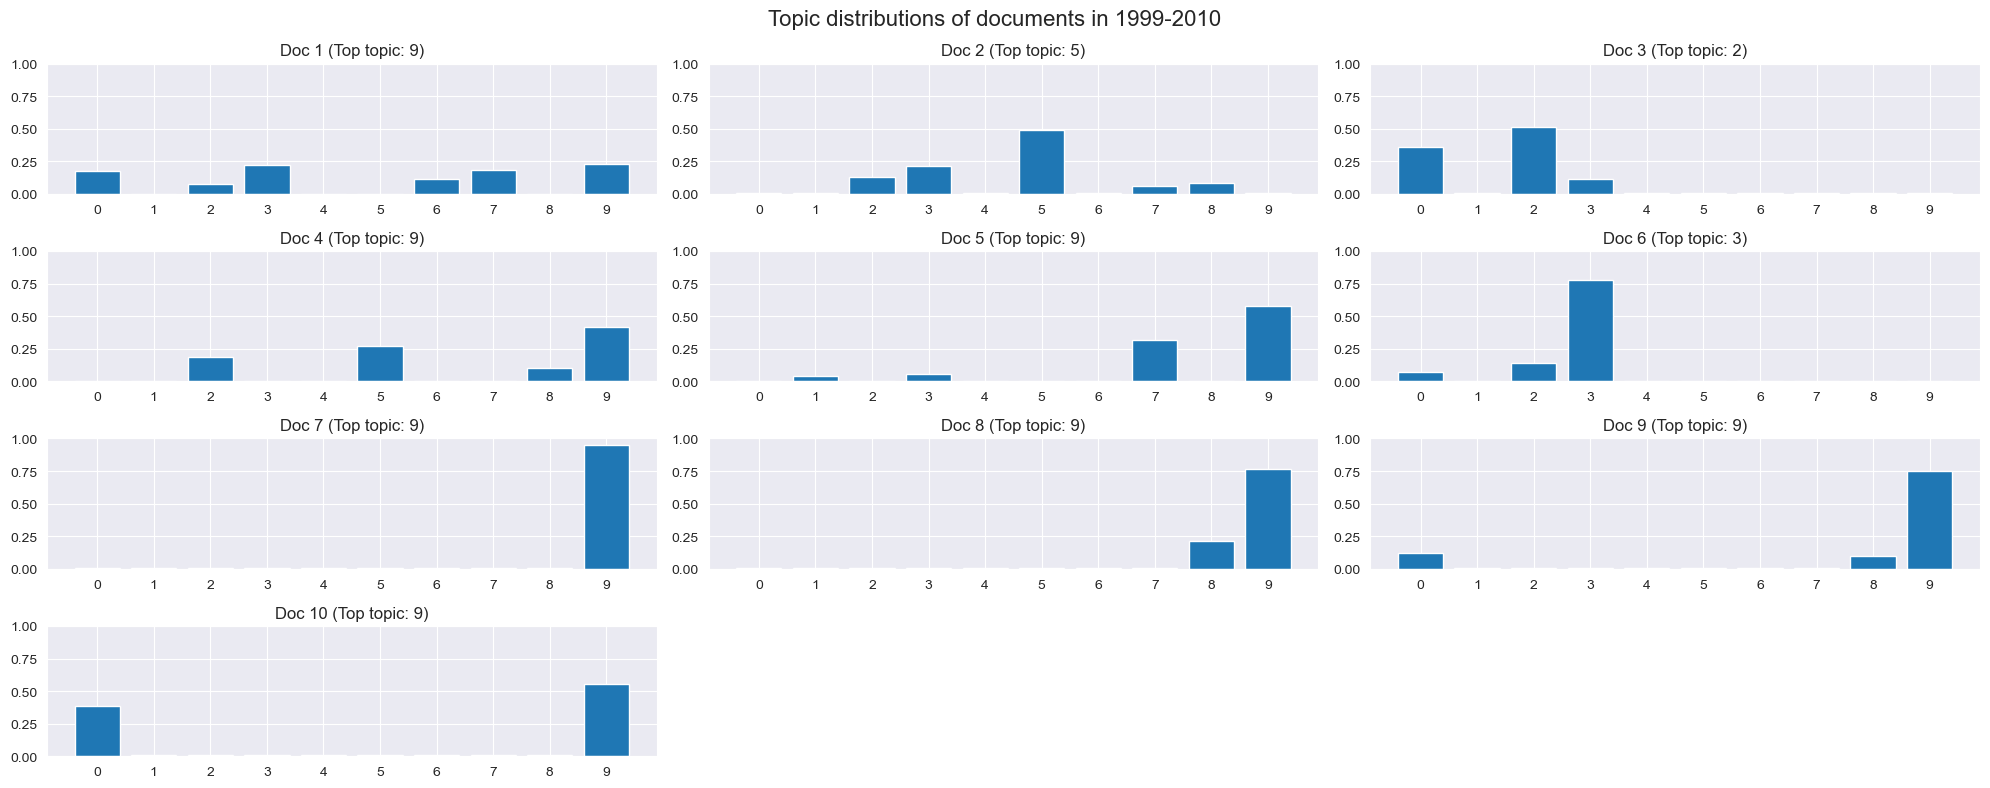

In [25]:
period_name = "1999-2010"
num_topics = global_lda.num_topics

thetas = get_topic_dists_in_period(period_name, df, global_lda, global_dictionary, token_col="tokens_bigram", max_num_docs=10)

plt.figure(figsize=(20, 8))
num_docs = len(thetas)

for d in range(num_docs):
    plot_theta(thetas, d, num_docs, num_topics)

plt.suptitle(f"Topic distributions of documents in {period_name}", fontsize=16)
plt.tight_layout()
plt.show()

In [26]:
period_name = "2007-2012"
num_topics = global_lda.num_topics

thetas = get_topic_dists_in_period(period_name, df, global_lda, global_dictionary, token_col="tokens_bigram", max_num_docs=10)

plt.figure(figsize=(20, 8))
num_docs = len(thetas)

for d in range(num_docs):
    plot_theta(thetas, d, num_docs, num_topics)

plt.suptitle(f"Topic distributions of documents in {period_name}", fontsize=16)
plt.tight_layout()
plt.show()

<Figure size 2000x800 with 0 Axes>

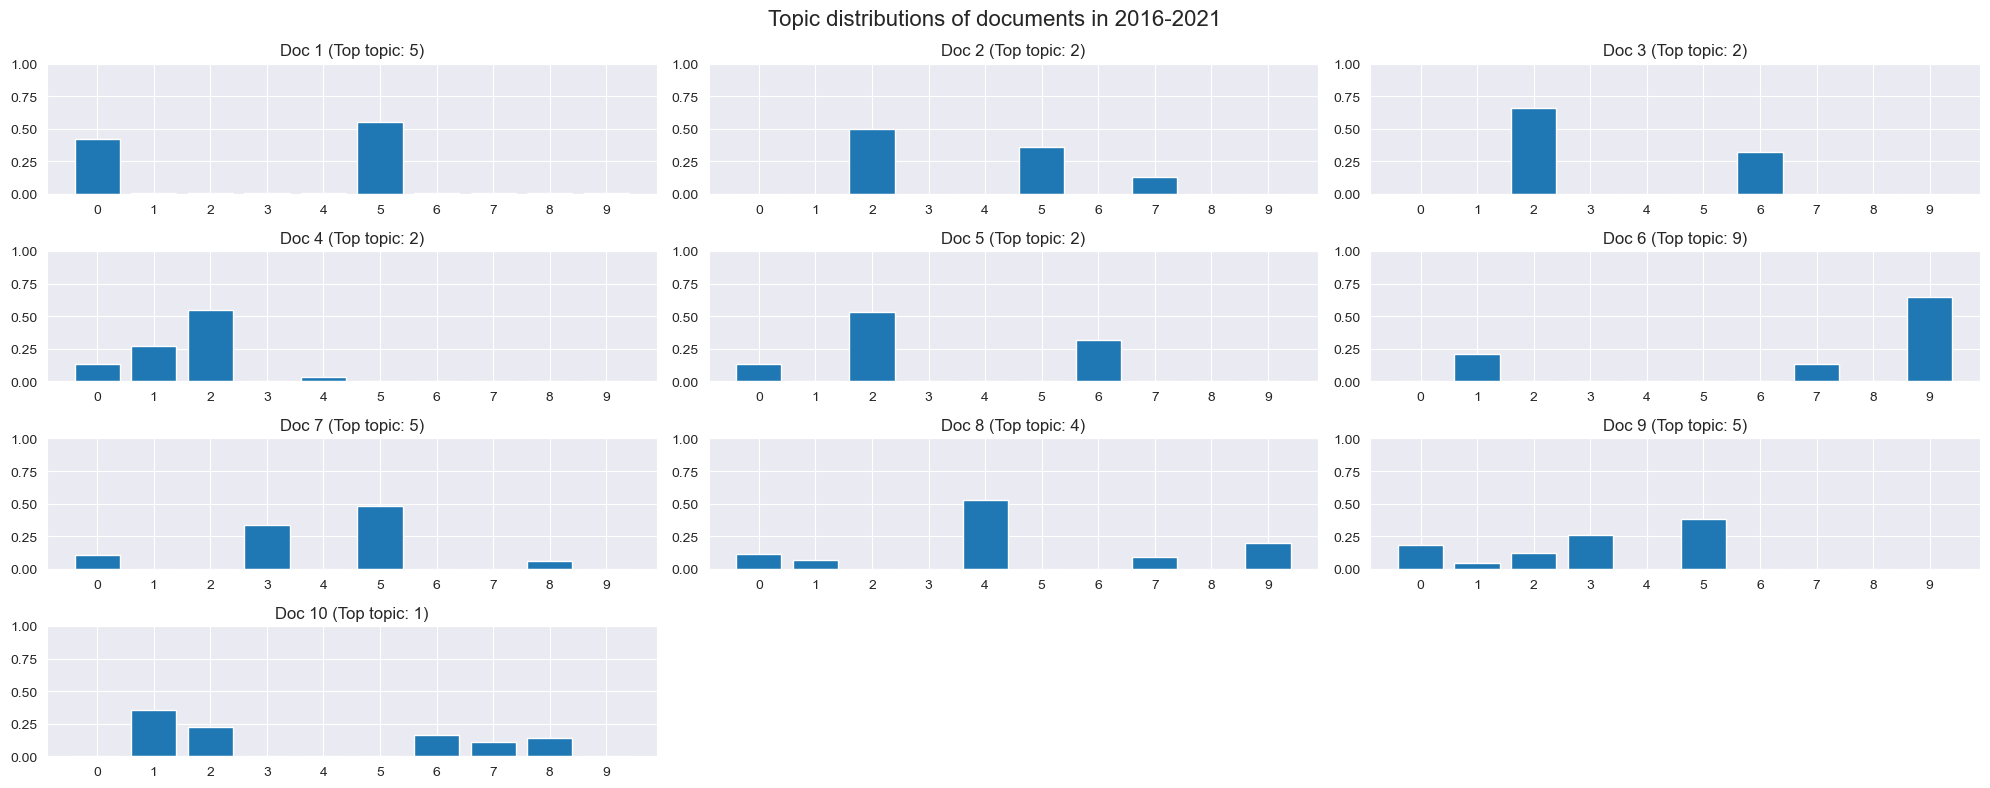

In [27]:
period_name = "2016-2021"
num_topics = global_lda.num_topics

thetas = get_topic_dists_in_period(period_name, df, global_lda, global_dictionary, token_col="tokens_bigram", max_num_docs=10)

plt.figure(figsize=(20, 8))
num_docs = len(thetas)

for d in range(num_docs):
    plot_theta(thetas, d, num_docs, num_topics)

plt.suptitle(f"Topic distributions of documents in {period_name}", fontsize=16)
plt.tight_layout()
plt.show()

In [28]:
#计算每个时期的topic
# Compute the mean topic distribution for each period.
# Steps:
# 1. infer the topic probability distribution of each document using the global LDA model
# 2. average these topic distributions within each period
#
# This gives:
# - the overall topic profile of each period in the shared global topic space
# - which topics are more prominent in each period
def get_period_mean_topics(df, lda_model, dictionary, periods, token_col="tokens_bigram", num_topics=global_lda.num_topics):
    mean_thetas = np.zeros((len(periods), num_topics))

    for i, period in enumerate(periods):
        subset = df[df["period"] == period]

        thetas = []
        for tokens in subset[token_col]:
            bow_vector = dictionary.doc2bow(tokens)
            theta_sparse = lda_model[bow_vector]
            theta_dense = convert_theta_sparse_to_dense(theta_sparse, num_topics)
            thetas.append(theta_dense)

        mean_theta = np.mean(thetas, axis=0)
        mean_thetas[i] = mean_theta

    return mean_thetas


periods = sorted(df["period"].unique())
num_topics = global_lda.num_topics

mean_thetas = get_period_mean_topics(
    df=df,
    lda_model=global_lda,
    dictionary=global_dictionary,
    periods=periods,
    token_col="tokens_bigram",
    num_topics=num_topics
)

print(mean_thetas.shape)
print(mean_thetas)

(3, 10)
[[0.09066253 0.03756025 0.09815726 0.07696933 0.01952237 0.11447157
  0.06538352 0.09495911 0.04137413 0.34394859]
 [0.09916169 0.06777469 0.093264   0.08680456 0.01858384 0.1208506
  0.08084929 0.12359869 0.06009654 0.235281  ]
 [0.16216027 0.09251591 0.05725376 0.15007212 0.05398332 0.06057318
  0.09157211 0.09589457 0.11084116 0.11470517]]


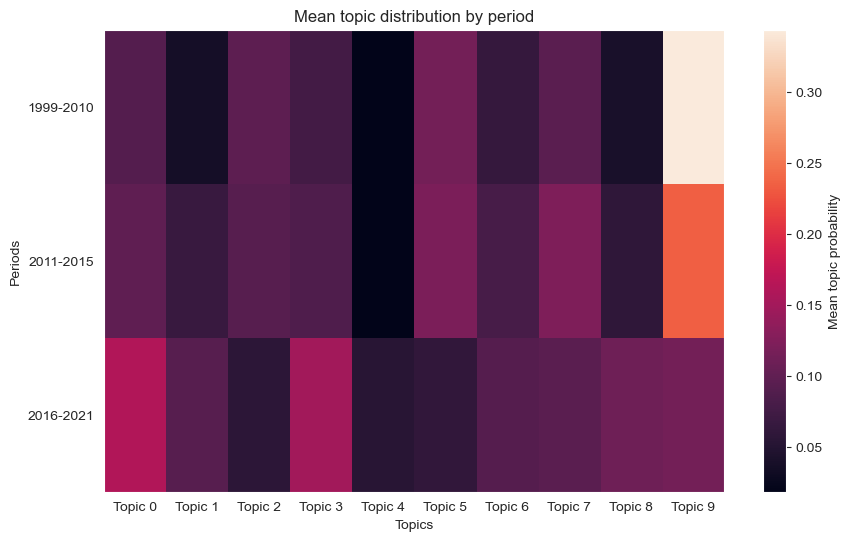

In [29]:
plt.figure(figsize=(10, 6))
plt.grid(False)
plt.imshow(mean_thetas, aspect="auto")
plt.colorbar(label="Mean topic probability")
plt.yticks(range(len(periods)), periods)
plt.xticks(range(num_topics), [f"Topic {i}" for i in range(num_topics)])
plt.xlabel("Topics")
plt.ylabel("Periods")
plt.title("Mean topic distribution by period")
plt.show()
# The heatmap shows that topic distributions differ across periods:
# - the early period (1999–2010) is most strongly associated with Topic 9, suggesting a stronger focus on early theoretical/strategy-oriented themes
# - the middle period (2011–2015) remains somewhat similar to the early period, but Topic 9 becomes less dominant and the distribution is more spread out
# - the later period (2016–2021) shows relatively higher weights on Topic 0 and Topic 3, while Topic 9 drops clearly,
#   indicating a shift away from earlier topics toward newer directions
#
# Overall, the topic profile changes substantially over time,
# suggesting that the focus of the field evolves gradually rather than staying fixed.


=== LDA COSINE SIMILARITY BETWEEN PERIODS ===
           1999-2010  2011-2015  2016-2021
1999-2010   1.000000   0.963160   0.744105
2011-2015   0.963160   1.000000   0.863566
2016-2021   0.744105   0.863566   1.000000


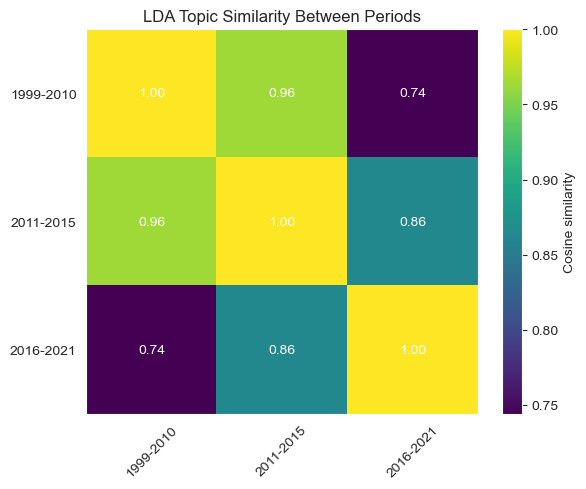

In [30]:
# LDA相似度矩阵
# Compute cosine similarity between periods
# based on their mean topic distributions (mean_thetas).
#
# This measures similarity in terms of topic composition,
# rather than raw word overlap.
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt

# 1. 用每个时期的平均topic分布计算相似度
lda_similarity_matrix = cosine_similarity(mean_thetas)

# 2. 转成DataFrame方便看
lda_similarity_df = pd.DataFrame(
    lda_similarity_matrix,
    index=periods,
    columns=periods
)

print("\n=== LDA COSINE SIMILARITY BETWEEN PERIODS ===")
print(lda_similarity_df)

# 3. 画热图
plt.figure(figsize=(6, 5))
plt.grid(False)
plt.imshow(lda_similarity_df, aspect="auto", cmap="viridis")
plt.colorbar(label="Cosine similarity")
plt.xticks(range(len(periods)), periods, rotation=45)
plt.yticks(range(len(periods)), periods)
plt.title("LDA Topic Similarity Between Periods")

# 4. 在格子里显示数值
for i in range(len(periods)):
    for j in range(len(periods)):
        plt.text(j, i, f"{lda_similarity_df.iloc[i, j]:.2f}",
                 ha="center", va="center", color="white")

plt.tight_layout()
plt.show()

# Compute cosine similarity between periods
# based on their mean topic distributions (mean_thetas).
#
# This measures similarity in terms of topic composition,
# rather than raw word overlap.


=== LDA COSINE DISTANCE BETWEEN PERIODS ===
              1999-2010  2011-2015  2016-2021
1999-2010 -2.220446e-16   0.036840   0.255895
2011-2015  3.683971e-02   0.000000   0.136434
2016-2021  2.558950e-01   0.136434   0.000000


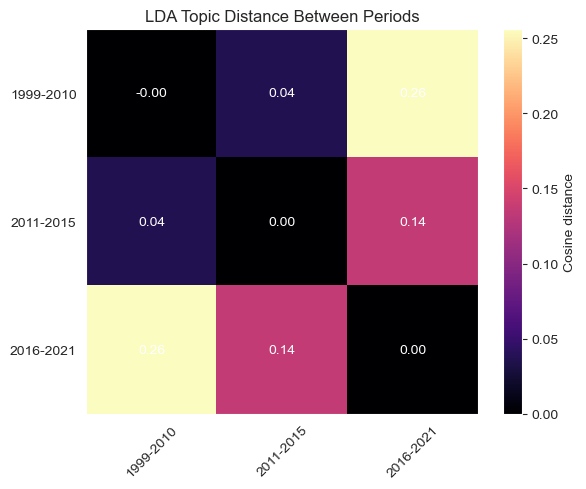

In [31]:
# LDA时期距离矩阵
# Compute cosine distance between periods based on mean topic distributions.
# Defined as:
# cosine distance = 1 - cosine similarity
#
# Interpretation:
# - closer to 0 → more similar
# - larger values → more different
lda_distance_matrix = 1 - cosine_similarity(mean_thetas)

lda_distance_df = pd.DataFrame(
    lda_distance_matrix,
    index=periods,
    columns=periods
)

print("\n=== LDA COSINE DISTANCE BETWEEN PERIODS ===")
print(lda_distance_df)

plt.figure(figsize=(6, 5))
plt.grid(False)
plt.imshow(lda_distance_df, aspect="auto", cmap="magma")
plt.colorbar(label="Cosine distance")
plt.xticks(range(len(periods)), periods, rotation=45)
plt.yticks(range(len(periods)), periods)
plt.title("LDA Topic Distance Between Periods")

for i in range(len(periods)):
    for j in range(len(periods)):
        plt.text(j, i, f"{lda_distance_df.iloc[i, j]:.2f}",
                 ha="center", va="center", color="white")

plt.tight_layout()
plt.show()

In [32]:
#BERTopic
from bertopic import BERTopic
# Apply BERTopic to the full corpus.
# The input is clean_text_embed, which preserves more semantic information
# and is more suitable for embedding-based topic modelling.
# Unlike LDA, BERTopic uses text embeddings to model semantic similarity,
# making it better suited for capturing documents that are semantically related
# even if they do not share the same surface words.
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np

texts = df["clean_text_embed"].tolist()
print(len(texts))
print(texts[0][:300])

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# embeddings = embedding_model.encode(texts)
# 
# print(embeddings.shape)

7015
This paper uncovers and explores the close relationship between Monte Carlo Optimization of a parametrized integral (MCO), Parametric machine-Learning (PL), and `blackbox' or `oracle'-based optimization (BO). We make four contributions. First, we prove that MCO is mathematically identical to a broad


In [33]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
# Define a CountVectorizer for BERTopic
# to generate representative keywords for each topic.
# Unigrams and bigrams are included to make topic words more specific.
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5
)
#Parameter tuning experiments can be conducted
#ngram_range=(1, 2)
# A (1,1) 只用单词 word-level 
# B (1,2) 单词 + 短语 phrase-level 
# C (1,2), min_df=10 高频短语 filtered phrases 


embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    verbose=True,
    calculate_probabilities=True,
    min_topic_size=50#Parameter tuning experiments can be conducted
)
topics, probs = topic_model.fit_transform(texts)

2026-04-16 20:27:36,814 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/220 [00:00<?, ?it/s]

2026-04-16 20:29:43,649 - BERTopic - Embedding - Completed ✓
2026-04-16 20:29:43,650 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-16 20:30:23,523 - BERTopic - Dimensionality - Completed ✓
2026-04-16 20:30:23,534 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-16 20:30:24,695 - BERTopic - Cluster - Completed ✓
2026-04-16 20:30:24,704 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-16 20:30:26,825 - BERTopic - Representation - Completed ✓


In [34]:
# Retrieve summary information of all topics
# (including topic id and document counts)
# 4. save results
df["bertopic_topic"] = topics
df["bertopic_prob"] = [p.max() if p is not None and len(p) > 0 else np.nan for p in probs]

# 5.topic info
topic_info = topic_model.get_topic_info()
# print(topic_info.head(15))
for topic_id in topic_info["Topic"].head(10):
    print(f"\n===== Topic {topic_id} =====")
    print(topic_model.get_topic(topic_id))
    
# 5b. visualize topics
# Each circle represents a topic:
# - circle size: number of documents in the topic (importance)
# - distance between circles: semantic difference between topics
fig_topics = topic_model.visualize_topics()
fig_topics.show()
# The extracted topics show clear semantic structure, for example:
# - Topic 0: Reinforcement Learning
# - Topic 1: Graph Neural Networks
# - Topic 5: Deep Neural Networks
# - Topic 6: Multi-armed Bandits
# - Topic 7: Generative Models (GANs)
# - Topic 8: Federated Learning
#
# These topics align well with major research directions in modern machine learning,
# indicating that BERTopic effectively captures semantic topics.

# Topic -1 represents outliers (documents not assigned to any clear topic).
# Its keywords are usually generic (data, model, method),
# indicating a lack of specific thematic focus.


# Compared to LDA, BERTopic produces more specific and semantically coherent topics,
# as it is based on embeddings rather than word frequency.


===== Topic -1 =====
[('data', 0.018596979622132907), ('learning', 0.01779881057187433), ('model', 0.013629383287985153), ('models', 0.011999858039504728), ('based', 0.011921438598193944), ('performance', 0.010654554325797688), ('method', 0.010484701280712948), ('methods', 0.010437493016967128), ('training', 0.010334860284122583), ('paper', 0.010326887884094861)]

===== Topic 0 =====
[('policy', 0.04041474959279658), ('reinforcement', 0.03393848638718767), ('reinforcement learning', 0.03383179077923444), ('rl', 0.03301203140991833), ('learning', 0.02884274738383617), ('agent', 0.021048414921000867), ('state', 0.018088167644483583), ('reward', 0.017093138224124053), ('policies', 0.016653427178110164), ('control', 0.015807728465371262)]

===== Topic 1 =====
[('graph', 0.0785106829954466), ('node', 0.03798315033245191), ('graphs', 0.03447601436469814), ('gnns', 0.024834219123988973), ('nodes', 0.02287818315767835), ('gnn', 0.02069515570415251), ('networks', 0.02016280614435082), ('graph 

In [35]:
# 6. topic distribution by period
topic_period_table = pd.crosstab(df["period"], df["bertopic_topic"], normalize="index")
print(topic_period_table)
# Compute topic distribution for each period (normalized proportions).
# Rows = periods
# Columns = topics
# Values = proportion of documents belonging to each topic

# Topic 2 (clustering / kernel methods) decreases in later periods,
# indicating a decline of traditional ML approaches.

# Topic 5 (deep learning) increases over time,
# showing the rise of neural networks in recent years.

# Topics such as Graph Neural Networks and Federated Learning
# appear mainly in the later period,
# indicating the emergence of new research directions.


# Topic 0 (Reinforcement Learning) is present across all periods
# and becomes more prominent in later years.

# The BERTopic results show that:
# - research shifts from traditional methods (e.g., SVM, clustering)
#   to modern approaches (deep learning, GNNs, federated learning)
# - topic structure becomes clearer over time (fewer outliers)
#
# This indicates a clear technological evolution of the field.

# Consistent with LDA results, but BERTopic provides more specific and interpretable topics

bertopic_topic       -1         0         1         2         3         4   \
period                                                                       
1999-2010       0.479508  0.061475  0.008197  0.098361  0.008197  0.168033   
2011-2015       0.396887  0.059339  0.017510  0.119650  0.019455  0.115759   
2016-2021       0.310117  0.106739  0.064949  0.031517  0.048755  0.021069   

bertopic_topic        5         6         7         8   ...        16  \
period                                                  ...             
1999-2010       0.004098  0.036885  0.004098  0.000000  ...  0.000000   
2011-2015       0.021401  0.053502  0.022374  0.007782  ...  0.000973   
2016-2021       0.041964  0.029950  0.033954  0.036218  ...  0.020547   

bertopic_topic        17        18        19        20        21        22  \
period                                                                       
1999-2010       0.012295  0.028689  0.000000  0.020492  0.004098  0.000000   
2011-2015

=== Cosine Similarity ===
period     1999-2010  2011-2015  2016-2021
period                                    
1999-2010   1.000000   0.989538   0.888822
2011-2015   0.989538   1.000000   0.911744
2016-2021   0.888822   0.911744   1.000000

=== Cosine Distance ===
period        1999-2010     2011-2015     2016-2021
period                                             
1999-2010 -6.661338e-16  1.046216e-02  1.111783e-01
2011-2015  1.046216e-02 -2.220446e-16  8.825601e-02
2016-2021  1.111783e-01  8.825601e-02 -2.220446e-16


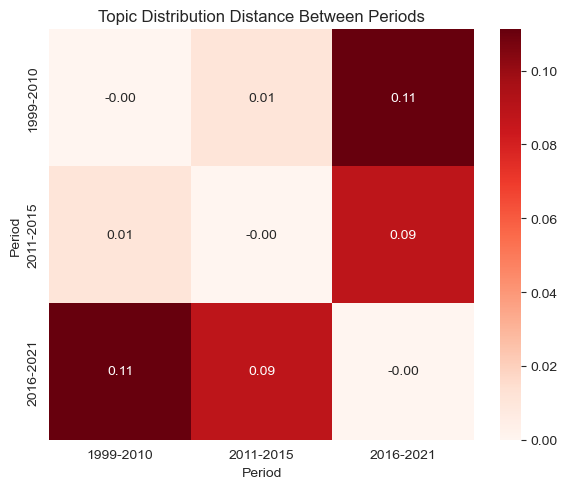

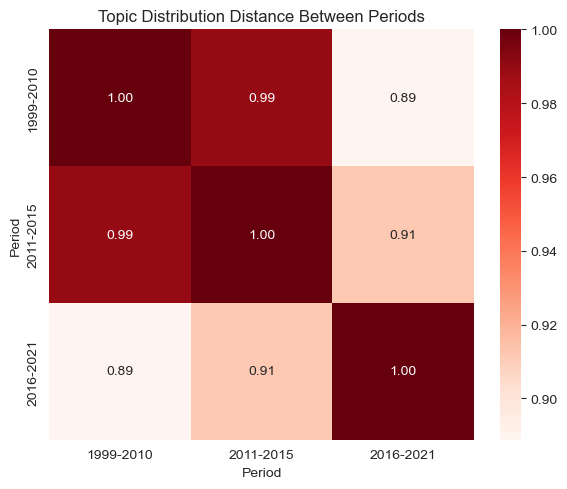

In [36]:
# Compute similarity and distance between periods
# based on BERTopic topic distributions (topic_period_table).
#
# Each row represents a topic distribution vector for a period,
# and cosine similarity is used to measure similarity.


# 7.不同时期 topic distribution 的距离矩阵和相似度矩阵
#计算不同时期之间的 topic distribution 距离
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# topic_period_table: row=period, coloumn=topic, 值=比例
sim_matrix = cosine_similarity(topic_period_table.values)
dist_matrix = 1 - sim_matrix

# 转成 DataFrame（方便展示）
sim_df = pd.DataFrame(
    sim_matrix,
    index=topic_period_table.index,
    columns=topic_period_table.index
)

dist_df = pd.DataFrame(
    dist_matrix,
    index=topic_period_table.index,
    columns=topic_period_table.index
)

print("=== Cosine Similarity ===")
print(sim_df)

print("\n=== Cosine Distance ===")
print(dist_df)

#画图
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(dist_df, annot=True, cmap="Reds", fmt=".2f")

plt.title("Topic Distribution Distance Between Periods")
plt.xlabel("Period")
plt.ylabel("Period")

plt.tight_layout()
plt.show()


#相似度图
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(sim_df, annot=True, cmap="Reds", fmt=".2f")

plt.title("Topic Distribution Distance Between Periods")
plt.xlabel("Period")
plt.ylabel("Period")

plt.tight_layout()
plt.show()




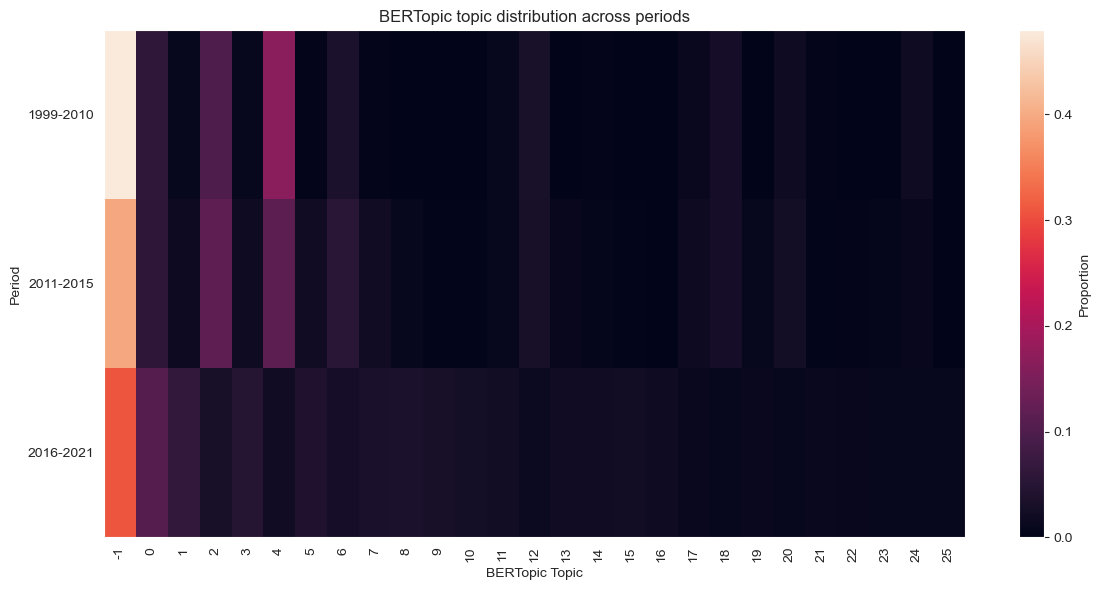

In [37]:

# 8. plot heatmap
# Visualise BERTopic topic distributions across periods using a heatmap.
#
# Rows (y-axis): periods
# Columns (x-axis): topic ids
# Colour: proportion of each topic in each period (darker = higher)
#
# This helps observe how topics evolve over time.
plt.figure(figsize=(12, 6))
plt.grid(False)
plt.imshow(topic_period_table, aspect="auto")
plt.colorbar(label="Proportion")
plt.yticks(range(len(topic_period_table.index)), topic_period_table.index)
plt.xticks(range(len(topic_period_table.columns)), topic_period_table.columns, rotation=90)
plt.xlabel("BERTopic Topic")
plt.ylabel("Period")
plt.title("BERTopic topic distribution across periods")
plt.tight_layout()
plt.show()

# The heatmap shows that(compare different topic):
# - topics become more structured over time
# - focus shifts from traditional methods to modern approaches (e.g., deep learning)
# - new topics (e.g., GNN, federated learning) emerge in later periods


=== Topic Distribution Table ===
bertopic_topic       -1         0         1         2         3         4   \
period                                                                       
1999-2010       0.479508  0.061475  0.008197  0.098361  0.008197  0.168033   
2011-2015       0.396887  0.059339  0.017510  0.119650  0.019455  0.115759   
2016-2021       0.310117  0.106739  0.064949  0.031517  0.048755  0.021069   

bertopic_topic        5         6         7         8   ...        16  \
period                                                  ...             
1999-2010       0.004098  0.036885  0.004098  0.000000  ...  0.000000   
2011-2015       0.021401  0.053502  0.022374  0.007782  ...  0.000973   
2016-2021       0.041964  0.029950  0.033954  0.036218  ...  0.020547   

bertopic_topic        17        18        19        20        21        22  \
period                                                                       
1999-2010       0.012295  0.028689  0.000000  0.020492

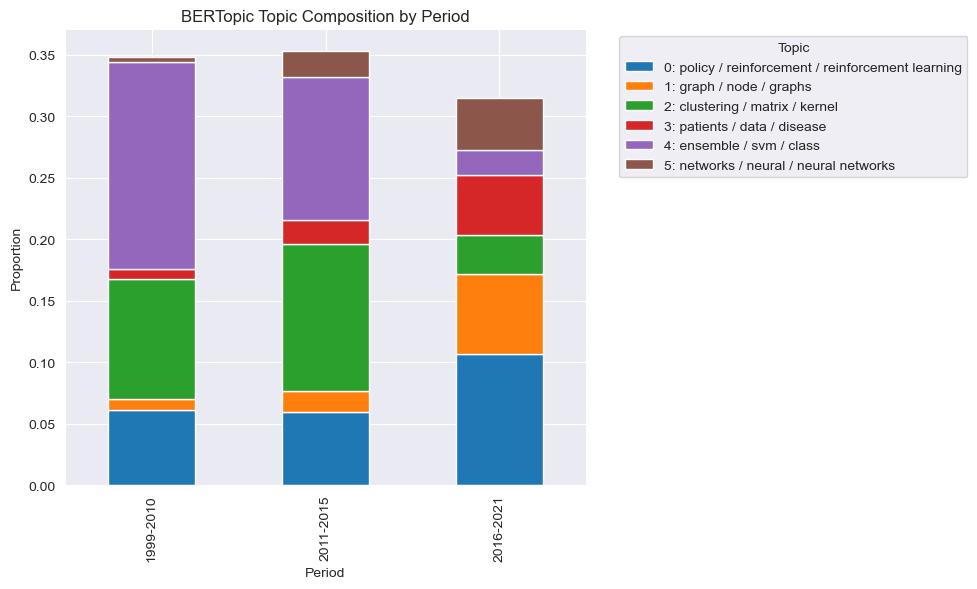

In [38]:

# 9. top topics per period

# Step 1: build topic × period 
topic_period = pd.crosstab(
    df["period"],
    df["bertopic_topic"],
    normalize="index"
)

print("=== Topic Distribution Table ===")
print(topic_period)

# Step 2: output each period  top topics（without outlier）
print("\n=== Top Topics Per Period (No Outliers) ===")

for period in topic_period.index:
    print(f"\n===== {period} =====")
    
    # delete outlier
    top_topics = topic_period.loc[period] \
                             .drop(-1, errors='ignore') \
                             .sort_values(ascending=False) \
                             .head(3)
    
    for tid, score in top_topics.items():
        print(f"\nTopic {tid} | proportion = {score:.3f}")
        print(topic_model.get_topic(tid))
        
# 9b. stacked bar: topic composition by period

def short_topic_name(topic_model, tid, top_n=3):
    words = topic_model.get_topic(tid)
    if words is None:
        return f"Topic {tid}"
    return " / ".join([w for w, _ in words[:top_n]])

# 选整体最常见的 top topics（delete outlier -1）
topic_counts = df["bertopic_topic"].value_counts().drop(-1, errors="ignore")
selected_topics = topic_counts.head(6).index.tolist()

# keep these  top topics
topic_period_top = topic_period[selected_topics].copy()

# give obvious label
rename_dict = {
    tid: f"{tid}: {short_topic_name(topic_model, tid, top_n=3)}"
    for tid in selected_topics
}
topic_period_top = topic_period_top.rename(columns=rename_dict)

#  stacked bar
ax = topic_period_top.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

ax.set_title("BERTopic Topic Composition by Period")
ax.set_xlabel("Period")
ax.set_ylabel("Proportion")
ax.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# After removing outliers, the dominant topics differ across periods:
#
# 1999–2010:
# - Topic 4 (SVM / classification) is the largest
# - Topic 2 (clustering / kernel) is second
# - this suggests an early focus on classical machine learning and classification
#
# 2011–2015:
# - Topic 2 and Topic 4 remain dominant
# - Topic 0 (reinforcement learning) starts to appear more clearly
# - this suggests that traditional methods remain strong, while new directions begin to emerge
#
# 2016–2021:
# - Topic 0 (reinforcement learning) becomes the top topic
# - Topic 1 (graph / GNN) rises clearly
# - Topic 3 (medical / clinical) enters the top group
# - this suggests that later research becomes more diverse, with more modern and application-oriented topics

# The stacked bar chart shows more clearly that:
# - Topic 4 and Topic 2 are more important in early/middle periods
# - Topic 0, Topic 1, Topic 3, and Topic 5 become more prominent later
# - this indicates a shift from traditional methods to reinforcement learning, graph learning, and deep learning

In [39]:

# 10. topic evolution over time
# This section analyzes how topics evolve over time in BERTopic.
# The year is first converted into datetime format and used as timestamps.
# The topics_over_time() function computes the frequency of each topic over time.
# The evolution_tuning parameter smooths temporal changes, while global_tuning
# ensures consistency of topics across time.
# The results are then reshaped into a "time × topic" matrix using pivot_table,
# which facilitates further analysis and visualization (e.g., line plots).

timestamps = pd.to_datetime(df["year"].astype(str), format="%Y")

topics_over_time = topic_model.topics_over_time(
    docs=texts,
    timestamps=timestamps,
    nr_bins=None,
    evolution_tuning=True,
    global_tuning=True
)

evo_pivot = topics_over_time.pivot_table(
    index="Timestamp",
    columns="Topic",
    values="Frequency",
    fill_value=0
)
print(evo_pivot.shape)
print(evo_pivot.head())

# 11. visualize topic evolution
fig = topic_model.visualize_topics_over_time(
    topics_over_time,
    top_n_topics=10
)

fig.show()

23it [00:04,  5.63it/s]

(23, 27)
Topic       -1    0    1    2    3    4    5    6    7    8   ...   16   17  \
Timestamp                                                     ...             
1999-01-01  0.0  2.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2000-01-01  1.0  0.0  0.0  1.0  0.0  2.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2001-01-01  0.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2002-01-01  1.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2003-01-01  2.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   

Topic        18   19   20   21   22   23   24   25  
Timestamp                                           
1999-01-01  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2000-01-01  0.0  0.0  2.0  0.0  0.0  0.0  0.0  0.0  
2001-01-01  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2002-01-01  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2003-01-01  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 27 columns]


In [40]:
#不同时间段topic分别计算
# This section groups the data by period and trains a separate BERTopic model for each time segment.
# Each model uses the same embedding and vectorizer configuration to ensure comparability across periods.
# After training, both the models and their corresponding topic information (e.g., topic IDs, document counts,
# and keyword representations) are stored in dictionaries for later analysis of topic structures in each period.
period_models = {}
period_topic_info = {}

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
)
print(df["period"].value_counts())
for period, group in df.groupby("period"):
    texts_period = group["clean_text_embed"].tolist()
    
    model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        verbose=True,
        calculate_probabilities=True,
        min_topic_size=30
    )
    
    topics, probs = model.fit_transform(texts_period)
    
    period_models[period] = model
    period_topic_info[period] = model.get_topic_info()
    
    # print(f"\n===== {period} =====")
    # print(model.get_topic_info().head(10))

2026-04-16 20:30:52,826 - BERTopic - Embedding - Transforming documents to embeddings.


period
2016-2021    5743
2011-2015    1028
1999-2010     244
Name: count, dtype: int64


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

2026-04-16 20:30:57,196 - BERTopic - Embedding - Completed ✓
2026-04-16 20:30:57,197 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-16 20:30:57,458 - BERTopic - Dimensionality - Completed ✓
2026-04-16 20:30:57,459 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-16 20:30:57,473 - BERTopic - Cluster - Completed ✓
2026-04-16 20:30:57,477 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-16 20:30:57,570 - BERTopic - Representation - Completed ✓
2026-04-16 20:30:57,629 - BERTopic - Embedding - Transforming documents to embeddings.



===== 1999-2010 =====
   Topic  Count                              Name  \
0     -1    244  -1_learning_algorithm_data_paper   

                                                                            Representation  \
0  [learning, algorithm, data, paper, problem, algorithms, using, based, method, function]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

...

2026-04-16 20:31:15,428 - BERTopic - Embedding - Completed ✓
2026-04-16 20:31:15,429 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-16 20:31:17,630 - BERTopic - Dimensionality - Completed ✓
2026-04-16 20:31:17,631 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-16 20:31:17,747 - BERTopic - Cluster - Completed ✓
2026-04-16 20:31:17,751 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-16 20:31:18,303 - BERTopic - Representation - Completed ✓
2026-04-16 20:31:18,637 - BERTopic - Embedding - Transforming documents to embeddings.



===== 2011-2015 =====
   Topic  Count                                                    Name  \
0     -1    362                        -1_learning_data_algorithm_model   
1      0    239                0_data_learning_classification_algorithm   
2      1    126                          1_deep_learning_networks_model   
3      2    105                        2_regret_algorithm_online_bandit   
4      3     65            3_learning_optimization_stochastic_algorithm   
5      4     62  4_policy_learning_reinforcement_reinforcement learning   
6      5     38                    5_clustering_data_algorithm_clusters   
7      6     31                          6_time_series_time series_data   

                                                                                                  Representation  \
0                         [learning, data, algorithm, model, methods, based, algorithms, method, problem, paper]   
1                    [data, learning, classification, algorithm, meth

Batches:   0%|          | 0/180 [00:00<?, ?it/s]

2026-04-16 20:33:01,666 - BERTopic - Embedding - Completed ✓
2026-04-16 20:33:01,667 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-16 20:33:03,078 - BERTopic - Dimensionality - Completed ✓
2026-04-16 20:33:03,079 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-16 20:33:03,827 - BERTopic - Cluster - Completed ✓
2026-04-16 20:33:03,832 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-16 20:33:06,968 - BERTopic - Representation - Completed ✓



===== 2016-2021 =====
   Topic  Count                                              Name  \
0     -1   1133                     -1_data_learning_model_models   
1      0    690                   0_neural_networks_training_deep   
2      1    582  1_policy_rl_reinforcement_reinforcement learning   
3      2    393                          2_graph_node_graphs_gnns   
4      3    340                     3_data_patients_disease_model   
5      4    277                4_clustering_data_matrix_algorithm   
6      5    266                 5_regret_bandit_algorithm_problem   
7      6    218         6_federated_privacy_federated learning_fl   
8      7    167                        7_label_labels_noisy_noise   
9      8    166                8_causal_explanations_model_models   

                                                                                                 Representation  \
0                                 [data, learning, model, models, based, neural, time, machine, method

In [41]:
#按时期分别看到 topic
for period, info in period_topic_info.items():
    print(f"\n===== {period} =====")
    print(info[["Topic", "Count", "Name", "Representation"]].head(10))
    
#The results show clear differences in topic structures across time periods.
# In the early period (1999–2010), most documents are assigned to the outlier topic (-1),
# indicating limited data or unstable semantic structure, making it difficult for the model
# to identify distinct topics.
# In the middle period (2011–2015), more coherent topics begin to emerge, such as deep learning,
# reinforcement learning, bandits, and clustering, suggesting increasing diversity and structure.
# In the later period (2016–2021), both the number and size of topics grow significantly,
# including neural networks, reinforcement learning, graph learning, as well as emerging areas
# like federated learning and causal inference, reflecting rapid expansion and specialization of the field.


===== 1999-2010 =====
   Topic  Count                              Name  \
0     -1    244  -1_learning_algorithm_data_paper   

                                                                            Representation  
0  [learning, algorithm, data, paper, problem, algorithms, using, based, method, function]  

===== 2011-2015 =====
   Topic  Count                                                    Name  \
0     -1    362                        -1_learning_data_algorithm_model   
1      0    239                0_data_learning_classification_algorithm   
2      1    126                          1_deep_learning_networks_model   
3      2    105                        2_regret_algorithm_online_bandit   
4      3     65            3_learning_optimization_stochastic_algorithm   
5      4     62  4_policy_learning_reinforcement_reinforcement learning   
6      5     38                    5_clustering_data_algorithm_clusters   
7      6     31                          6_time_series_time s

In [42]:
#berttopic对比实验
# This section defines a unified BERTopic experiment function to systematically compare
# how different parameter settings affect topic modeling results.
# The function allows changes to the embedding model, clustering method
# (default HDBSCAN or KMeans), outlier reduction, minimum topic size, and number of clusters.
# Four experiments are then run on the same corpus:
# A) baseline; B) baseline + reduce_outliers; C) KMeans clustering; D) MPNet embedding.
# This makes it possible to compare topic quantity, topic quality, and interpretability
# under different BERTopic configurations.
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
#主函数
def run_bertopic_experiment(
    texts,
    embedding_name="all-MiniLM-L6-v2",
    use_kmeans=False,
    reduce_outliers_flag=False,
    min_topic_size=50,
    n_clusters=20
):
    
    print(f"\n===== Running BERTopic =====")
    print(f"Embedding: {embedding_name}")
    print(f"KMeans: {use_kmeans}")
    print(f"Reduce outliers: {reduce_outliers_flag}")
    
    # embedding
    embedding_model = SentenceTransformer(embedding_name)
    
    # vectorizer
    vectorizer_model = CountVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=5
    )
    
    # clustering
    if use_kmeans:
        cluster_model = KMeans(n_clusters=n_clusters, random_state=42)
    else:
        cluster_model = None
    
    # model
    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        hdbscan_model=cluster_model,
        calculate_probabilities=True,
        verbose=True,
        min_topic_size=min_topic_size
    )
    
    # train
    topics, probs = topic_model.fit_transform(texts)
    
    # reduce outliers
    if reduce_outliers_flag:
        print("Reducing outliers...")
        topics = topic_model.reduce_outliers(
            texts,
            topics,
            strategy="c-tf-idf"
        )
    
    return topic_model, topics, probs

In [43]:
#baseline
model_A, topics_A, probs_A = run_bertopic_experiment(
    texts,
    embedding_name="all-MiniLM-L6-v2",
    use_kmeans=False,
    reduce_outliers_flag=False
)




===== Running BERTopic =====
Embedding: all-MiniLM-L6-v2
KMeans: False
Reduce outliers: False


2026-04-16 20:33:12,954 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/220 [00:00<?, ?it/s]

2026-04-16 20:35:26,852 - BERTopic - Embedding - Completed ✓
2026-04-16 20:35:26,853 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-16 20:35:28,457 - BERTopic - Dimensionality - Completed ✓
2026-04-16 20:35:28,458 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-16 20:35:29,406 - BERTopic - Cluster - Completed ✓
2026-04-16 20:35:29,411 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-16 20:35:31,613 - BERTopic - Representation - Completed ✓


In [44]:
#+ reduce_outliers
model_B, topics_B, probs_B = run_bertopic_experiment(
    texts,
    embedding_name="all-MiniLM-L6-v2",
    use_kmeans=False,
    reduce_outliers_flag=True
)


===== Running BERTopic =====
Embedding: all-MiniLM-L6-v2
KMeans: False
Reduce outliers: True


2026-04-16 20:35:35,452 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/220 [00:00<?, ?it/s]

2026-04-16 20:37:46,902 - BERTopic - Embedding - Completed ✓
2026-04-16 20:37:46,903 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-16 20:37:49,291 - BERTopic - Dimensionality - Completed ✓
2026-04-16 20:37:49,293 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-16 20:37:50,787 - BERTopic - Cluster - Completed ✓
2026-04-16 20:37:50,799 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-16 20:37:53,502 - BERTopic - Representation - Completed ✓


Reducing outliers...


In [45]:
#K-means
model_C, topics_C, probs_C = run_bertopic_experiment(
    texts,
    embedding_name="all-MiniLM-L6-v2",
    use_kmeans=True,
    reduce_outliers_flag=False
)


===== Running BERTopic =====
Embedding: all-MiniLM-L6-v2
KMeans: True
Reduce outliers: False


2026-04-16 20:37:58,451 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/220 [00:00<?, ?it/s]

2026-04-16 20:40:13,556 - BERTopic - Embedding - Completed ✓
2026-04-16 20:40:13,557 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-16 20:40:15,139 - BERTopic - Dimensionality - Completed ✓
2026-04-16 20:40:15,141 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-16 20:40:23,224 - BERTopic - Cluster - Completed ✓
2026-04-16 20:40:23,230 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-16 20:40:25,444 - BERTopic - Representation - Completed ✓


In [46]:
#MPNet embedding
model_D, topics_D, probs_D = run_bertopic_experiment(
    texts,
    embedding_name="all-mpnet-base-v2",
    use_kmeans=False,
    reduce_outliers_flag=False
)


===== Running BERTopic =====
Embedding: all-mpnet-base-v2
KMeans: False
Reduce outliers: False


2026-04-16 20:40:29,586 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/220 [00:00<?, ?it/s]

2026-04-16 20:59:02,162 - BERTopic - Embedding - Completed ✓
2026-04-16 20:59:02,166 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-16 20:59:03,976 - BERTopic - Dimensionality - Completed ✓
2026-04-16 20:59:03,979 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-16 20:59:04,931 - BERTopic - Cluster - Completed ✓
2026-04-16 20:59:04,943 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-16 20:59:07,253 - BERTopic - Representation - Completed ✓


In [54]:
#对比分析

# This section provides a unified analysis of BERTopic experiment results.
# The function adds the topic assignments back to the dataset, computes the outlier ratio
# (proportion of Topic = -1), builds a topic distribution table by period,
# and prints the top 3 topics with keywords for each time segment.
# This allows different experiment settings to be compared using the same criteria:
# noise level, topic distribution, and topic interpretability.
def analyze_topic_info(df, topics, topic_model, name="Experiment"):

    df_temp = df.copy()
    df_temp["topic"] = topics

    print(f"\n===== {name} =====")

    # outlier ratio
    outlier_ratio = (df_temp["topic"] == -1).mean()
    print(f"Outlier ratio: {outlier_ratio:.3f}")

    # topic distribution
    topic_period = pd.crosstab(
        df_temp["period"],
        df_temp["topic"],
        normalize="index"
    )

    print("\nTop topics per period:")

    for period in topic_period.index:
        print(f"\n--- {period} ---")

        top_topics = topic_period.loc[period] \
            .drop(-1, errors='ignore') \
            .sort_values(ascending=False) \
            .head(5)

        for tid, score in top_topics.items():
            print(f"\nTopic {tid} ({score:.3f})")
            print(topic_model.get_topic(tid))

    return topic_period
tp_A = analyze_topic_info(df, topics_A, model_A, "Baseline")
tp_B = analyze_topic_info(df, topics_B, model_B, "Reduce Outliers")
tp_C = analyze_topic_info(df, topics_C, model_C, "KMeans")
tp_D = analyze_topic_info(df, topics_D, model_D, "MPNet")


===== Baseline =====
Outlier ratio: 0.337

Top topics per period:

--- 1999-2010 ---

Topic 9 (0.131)
[('svm', 0.03725554208761579), ('margin', 0.023618640970669895), ('learning', 0.022142148412650255), ('dimension', 0.02179784777135033), ('support', 0.02105303442322752), ('vc', 0.019246420943037423), ('bounds', 0.019070155505665883), ('algorithm', 0.019029149686615874), ('support vector', 0.01899189412622099), ('complexity', 0.018833360159723558)]

Topic 0 (0.061)
[('policy', 0.04008968926565491), ('reinforcement', 0.03402117398656972), ('reinforcement learning', 0.03377527225486844), ('rl', 0.03273398222583555), ('learning', 0.028510914060997962), ('agent', 0.020811541806167604), ('state', 0.01807793986787233), ('reward', 0.016983058152846165), ('policies', 0.01656183242490867), ('control', 0.015708477692222955)]

Topic 11 (0.049)
[('matrix', 0.05032660674419645), ('kernel', 0.028607489944717412), ('rank', 0.02406960272192322), ('factorization', 0.023395412098509188), ('data', 0.018


EXPERIMENT: Baseline

[Baseline] Outlier ratio: 0.337


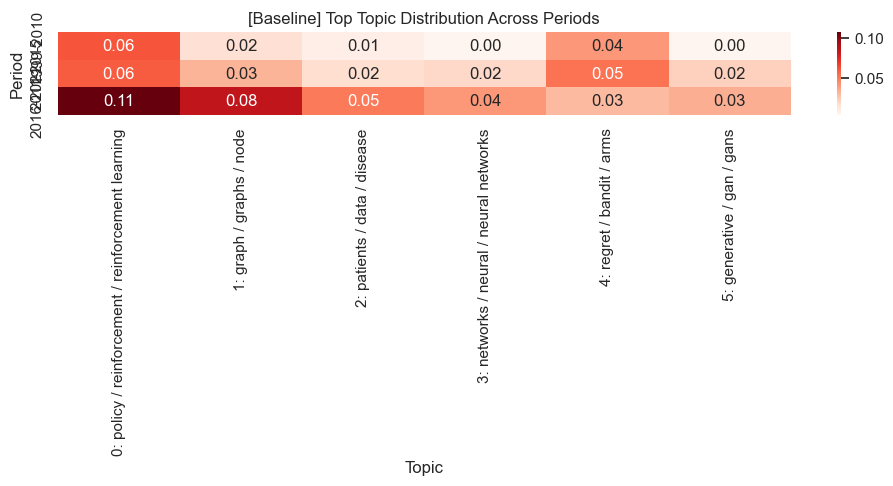

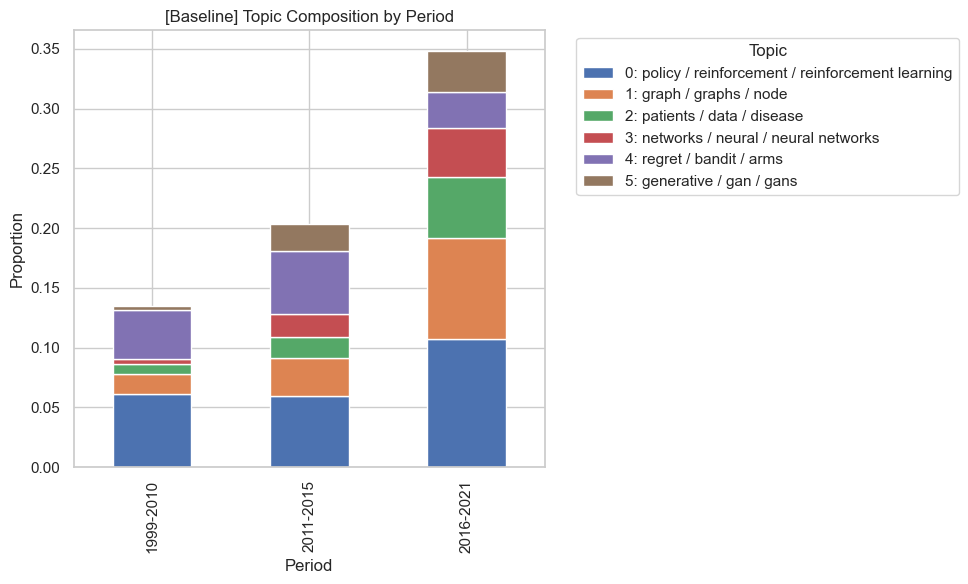


[Baseline] Generating topic evolution plot...


23it [00:03,  6.14it/s]



EXPERIMENT: Reduce Outliers

[Reduce Outliers] Outlier ratio: 0.000


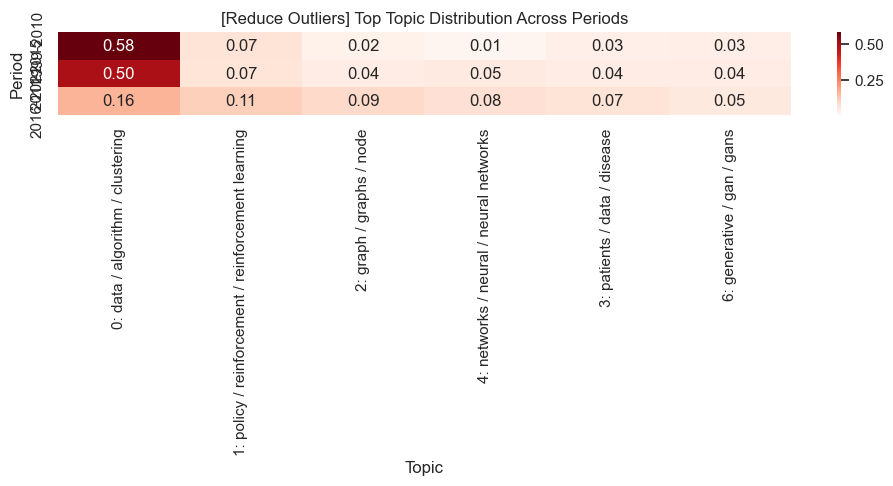

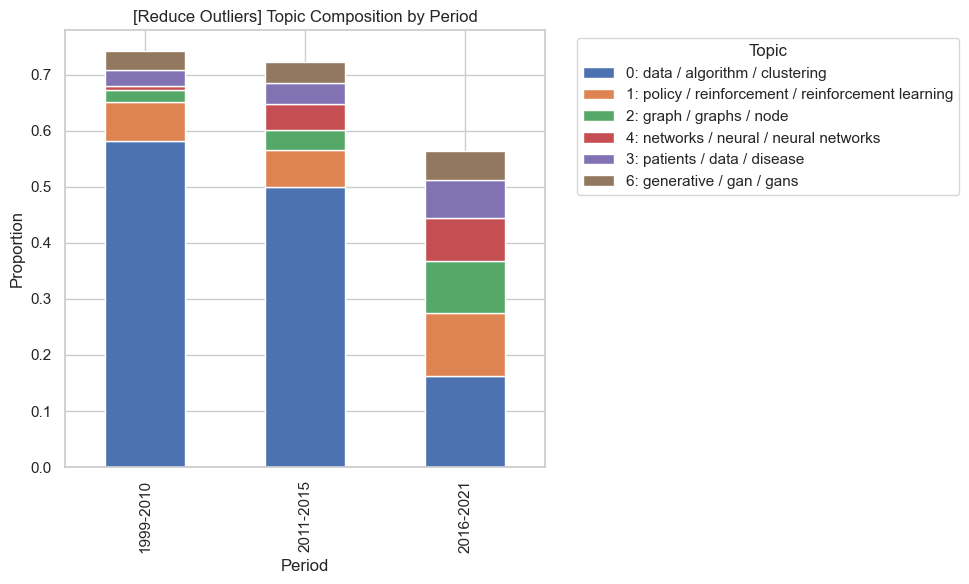


[Reduce Outliers] Generating topic evolution plot...


23it [00:03,  6.61it/s]



EXPERIMENT: KMeans

[KMeans] Outlier ratio: 0.000


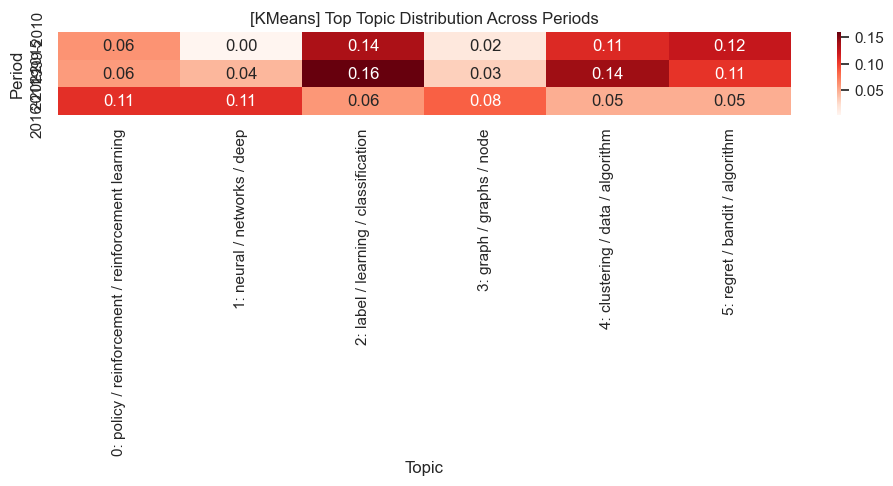

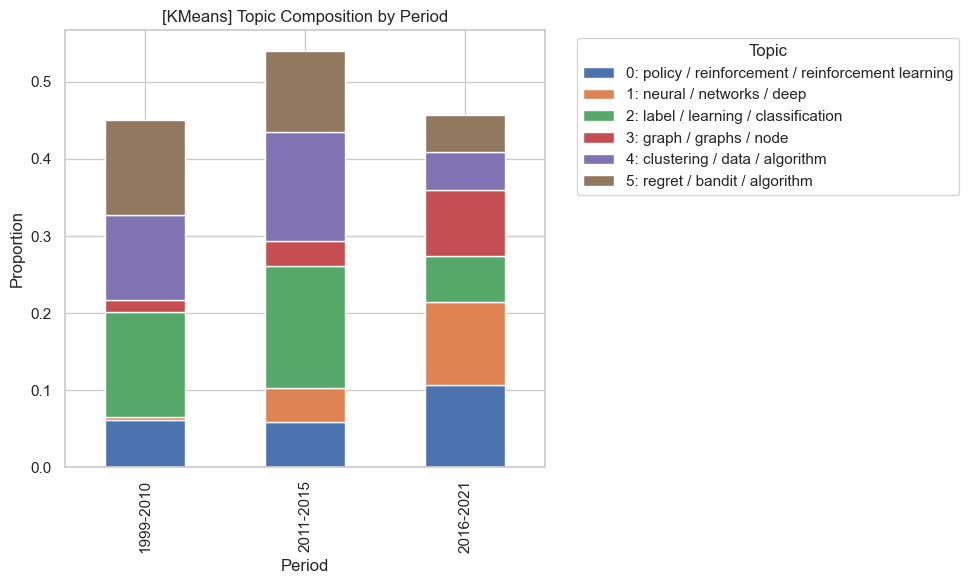


[KMeans] Generating topic evolution plot...


23it [00:04,  5.67it/s]



EXPERIMENT: MPNet

[MPNet] Outlier ratio: 0.232


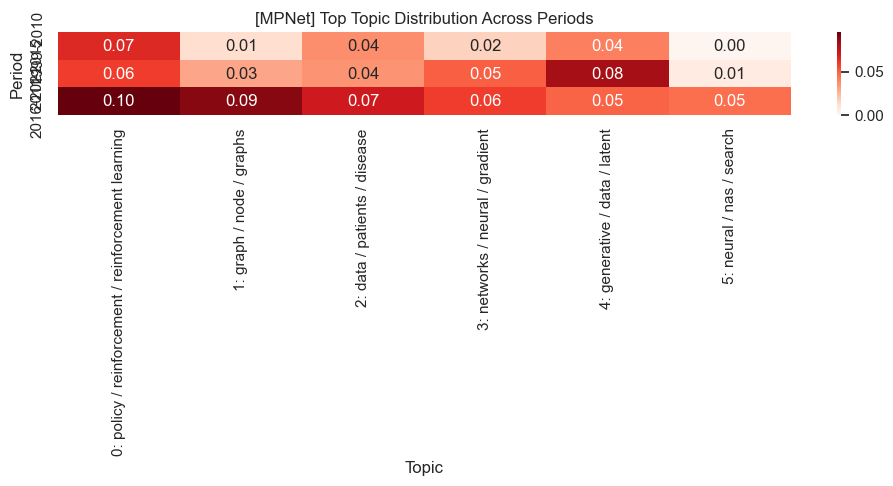

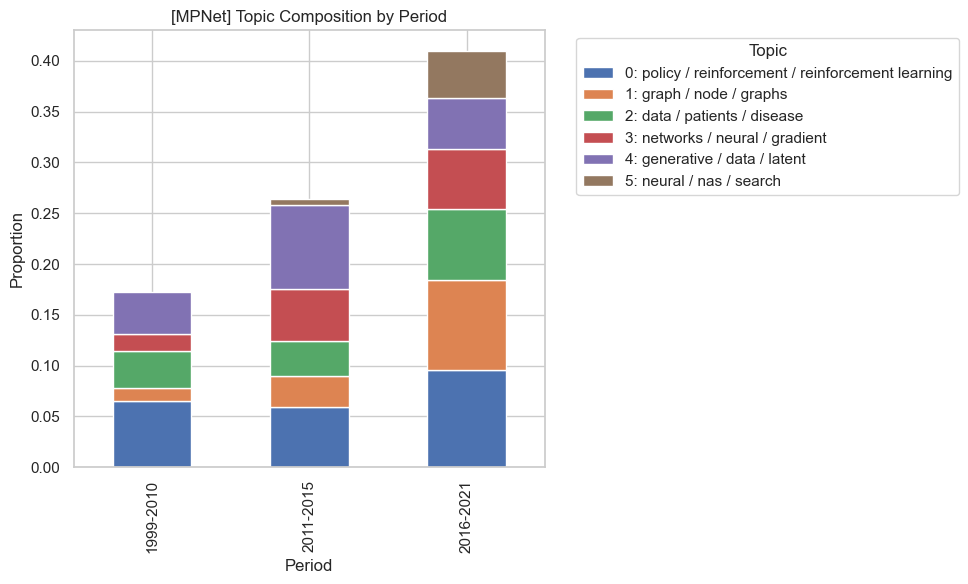


[MPNet] Generating topic evolution plot...


23it [00:07,  3.19it/s]


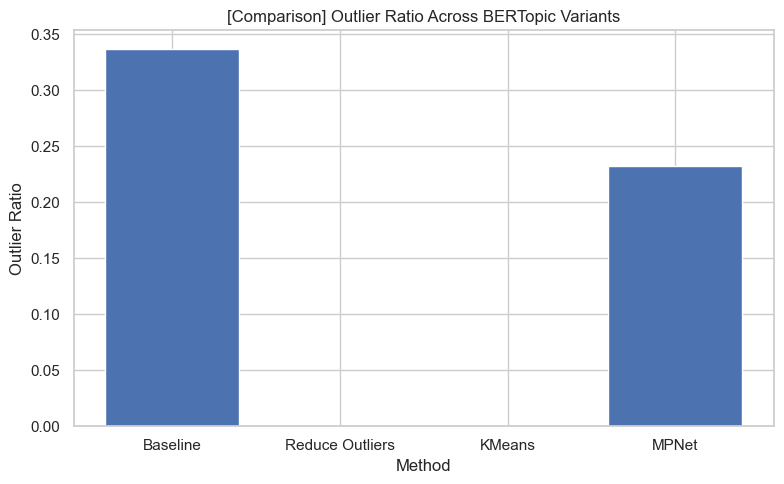


=== Outlier Ratio Summary ===
            Method  Outlier Ratio
0         Baseline       0.336565
1  Reduce Outliers       0.000000
2           KMeans       0.000000
3            MPNet       0.232217


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#This code implements a complete BERTopic analysis pipeline.
# It first defines a helper function (short_topic_name) to create readable labels for topics.
# Then, the analyze_results function performs a structured analysis for each experiment, including:
# (1) computing outlier ratio,
# (2) building topic distribution across time periods,
# (3) visualizing dominant topics using heatmaps and stacked bar charts,
# (4) analyzing topic evolution over time using topics_over_time.
# The function returns structured outputs for further comparison.
#
# In the main workflow, this function is applied to four BERTopic configurations
# (Baseline, Reduce Outliers, KMeans, MPNet), and their results are compared.
# Finally, a bar chart is used to visualize differences in outlier ratios.
sns.set_theme(style="whitegrid")




# give topic short label

def short_topic_name(topic_model, tid, top_n=3):
    words = topic_model.get_topic(tid)
    if words is None:
        return f"Topic {tid}"
    return " / ".join([w for w, _ in words[:top_n]])



# single test+visual

def analyze_results(df, topics, topic_model, name="Experiment", top_n_topics=6):
    
    print("\n" + "=" * 60)
    print(f"EXPERIMENT: {name}")
    print("=" * 60)
    
    df_temp = df.copy()
    df_temp["topic"] = topics
    
    #  outlier ratio
    outlier_ratio = (df_temp["topic"] == -1).mean()
    print(f"\n[{name}] Outlier ratio: {outlier_ratio:.3f}")
    
    #  topic distribution by period
    topic_period = pd.crosstab(
        df_temp["period"],
        df_temp["topic"],
        normalize="index"
    )
    
    
    # 选整体最常见的 top topics（去掉 -1）
    topic_counts = df_temp["topic"].value_counts().drop(-1, errors="ignore")
    selected_topics = topic_counts.head(top_n_topics).index.tolist()
    
    topic_period_top = topic_period[selected_topics].copy()
    
    # 给列换成更直观的标签
    rename_dict = {
        tid: f"{tid}: {short_topic_name(topic_model, tid, top_n=3)}"
        for tid in selected_topics
    }
    topic_period_top_renamed = topic_period_top.rename(columns=rename_dict)
    

    # Heatmap

    plt.figure(figsize=(10, 5))
    sns.heatmap(topic_period_top_renamed, annot=True, cmap="Reds", fmt=".2f")
    plt.title(f"[{name}] Top Topic Distribution Across Periods")
    plt.xlabel("Topic")
    plt.ylabel("Period")
    plt.tight_layout()
    plt.show()
    

    # Stacked bar

    ax = topic_period_top_renamed.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6)
    )
    ax.set_title(f"[{name}] Topic Composition by Period")
    ax.set_ylabel("Proportion")
    ax.set_xlabel("Period")
    ax.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    

    # Topic evolution over time

    print(f"\n[{name}] Generating topic evolution plot...")
    
    timestamps = pd.to_datetime(df_temp["year"].astype(str), format="%Y")
    
    topics_over_time = topic_model.topics_over_time(
        docs=df_temp["clean_text_embed"].tolist(),
        timestamps=timestamps,
        nr_bins=None,
        evolution_tuning=True,
        global_tuning=True
    )
    
    fig = topic_model.visualize_topics_over_time(
        topics_over_time,
        top_n_topics=min(10, len(selected_topics))
    )
    fig.update_layout(title=f"{name}: Topic Evolution Over Time")
    fig.show()
    
    return {
        "topic_period": topic_period,
        "topic_period_top": topic_period_top_renamed,
        "outlier_ratio": outlier_ratio,
        "topics_over_time": topics_over_time
    }



#analysis four model

res_A = analyze_results(df, topics_A, model_A, "Baseline", top_n_topics=6)
res_B = analyze_results(df, topics_B, model_B, "Reduce Outliers", top_n_topics=6)
res_C = analyze_results(df, topics_C, model_C, "KMeans", top_n_topics=6)
res_D = analyze_results(df, topics_D, model_D, "MPNet", top_n_topics=6)

tp_A = res_A["topic_period"]
tp_B = res_B["topic_period"]
tp_C = res_C["topic_period"]
tp_D = res_D["topic_period"]



# 4. Outlier ratio compare

outlier_summary = pd.DataFrame({
    "Method": ["Baseline", "Reduce Outliers", "KMeans", "MPNet"],
    "Outlier Ratio": [
        res_A["outlier_ratio"],
        res_B["outlier_ratio"],
        res_C["outlier_ratio"],
        res_D["outlier_ratio"]
    ]
})

plt.figure(figsize=(8, 5))
plt.bar(outlier_summary["Method"], outlier_summary["Outlier Ratio"])
plt.title("[Comparison] Outlier Ratio Across BERTopic Variants")
plt.ylabel("Outlier Ratio")
plt.xlabel("Method")
plt.tight_layout()
plt.show()

print("\n=== Outlier Ratio Summary ===")
print(outlier_summary)


# This experiment compares four BERTopic variants (Baseline, Reduce Outliers, KMeans, MPNet)
# to evaluate their performance in terms of noise handling, topic interpretability, and temporal consistency.
#
# Baseline (HDBSCAN) produces clean and interpretable topics but has a high outlier ratio (~33%),
# meaning many documents are not assigned to any topic.
#
# Reduce Outliers eliminates all outliers (0%) by reassigning noise points, improving coverage,
# but results in overly broad topics (e.g., one dominant "data/algorithm" topic), reducing interpretability.
#
# KMeans also removes outliers (0%) and produces more balanced and stable topic distributions across periods,
# achieving the best trade-off between coverage, topic clarity, and temporal consistency.
#
# MPNet (stronger embeddings) improves semantic coherence (e.g., better capture of GNNs, GANs, medical topics),
# but still retains moderate outliers (~23%), showing clustering still plays a key role.
#
# Across all models, a consistent temporal trend is observed:
# early ML (SVM, kernel methods) → mid-stage (bandits, RL) → recent (deep learning, GNNs, applications),
# which aligns with real-world ML development and validates the modeling approach.
#
# Overall, KMeans-based BERTopic is the most balanced choice, while MPNet enhances semantic richness.
# Excessive outlier reduction improves coverage but harms topic granularity.

In [ ]:
# BERTopic Variants Comparative Analysis
# 1. Experimental Design Motivation
# 
# To systematically evaluate the robustness and interpretability of BERTopic, four model variants were designed:
# 
# Baseline: Standard BERTopic pipeline as a reference model
# Reduce Outliers: Applies outlier reduction to reassign noise points
# KMeans-based BERTopic: Replaces HDBSCAN with KMeans for deterministic clustering
# MPNet Embedding: Uses a stronger embedding model to improve semantic representation
# 
# The goal of this design is to analyze topic modeling performance from three critical dimensions:
# 
# Noise handling ability (outlier ratio)
# Topic interpretability and stability
# Temporal evolution consistency across periods
# 2. Model Differences
# Model	Key Difference	Expected Effect
# Baseline	HDBSCAN clustering	Flexible but produces many outliers
# Reduce Outliers	Post-process reassignment	Lower noise, but may blur topics
# KMeans	Fixed number of clusters	No outliers, more structured topics
# MPNet	Better embeddings	More semantic topics, fewer noisy splits
# 3. Expected Hypotheses
# 
# Before running the experiments, we hypothesize:
# 
# Baseline → High outlier ratio, but clean core topics
# Reduce Outliers → Lower noise, but risk of overly broad topics
# KMeans → Balanced structure, clearer topic coverage
# MPNet → Better semantic coherence, moderate outliers
# 4. Experimental Results & Analysis
# 4.1 Outlier Ratio Comparison
# Model	Outlier Ratio
# Baseline	0.337
# Reduce Outliers	0.000
# KMeans	0.000
# MPNet	0.232
# 
# Analysis:
# 
# Baseline produces a very high proportion of noise (33.7%), indicating that HDBSCAN is strict.
# Reduce Outliers and KMeans completely eliminate outliers.
# MPNet reduces noise compared to Baseline but still retains 23.2%, showing it is still selective.
# 
# Key insight:
# Outlier removal trades off precision → coverage.
# 
# 4.2 Topic Evolution Over Time
# 
# Across all models, several consistent research trends emerge:
# 
# Early period (1999–2010)
# Dominated by:
# SVM / margin theory
# Online learning / regret
# Reinforcement learning
# Middle period (2011–2015)
# Transition phase:
# Bandits / regret becomes stable
# Reinforcement learning grows
# Traditional ML still dominant
# Recent period (2016–2021)
# Clear emergence of:
# Graph Neural Networks (GNNs)
# Deep learning / neural networks
# Healthcare applications
# 
# This matches real-world ML evolution, which validates your modeling pipeline.
# 
# 4.3 Model-wise Behaviour
# (1) Baseline
# Topics are clean and interpretable
# Clearly identifies:
# SVM → RL → GNN progression
# BUT:
# High outlier ratio → loses many documents
# 
# Conclusion: High precision, low coverage
# 
# (2) Reduce Outliers
# Outliers reduced to 0%
# However:
# One dominant topic ("data / algorithm / clustering")
# Covers up to 58% of early period
# 
# Problem:
# 
# Topics become too generic
# Loses fine-grained structure
# 
# Conclusion: High coverage, low specificity
# 
# (3) KMeans
# No outliers
# Topics are:
# More evenly distributed
# Clearly separated (classification, clustering, RL, GNN)
# Temporal trends are very stable
# 
# Example:
# 
# 2016–2021:
# Deep learning emerges clearly
# RL and GNN coexist
# 
# Conclusion: Best balance between structure and interpretability
# 
# (4) MPNet
# Better semantic grouping:
# Captures generative models (GANs) earlier
# Better grouping of "latent / generative / neural"
# Still has moderate outliers (23%)
# 
# Conclusion:
# Better semantics, but still depends on clustering behavior
# 
# 5. Key Findings
# Finding 1: Trade-off between noise and interpretability
# Removing outliers improves coverage
# But excessive merging reduces topic clarity
# Finding 2: Clustering method matters more than embedding
# KMeans (simple clustering) produced:
# Most stable topic distributions
# Best temporal consistency
# Finding 3: Embedding improves semantic richness
# MPNet captures:
# Generative models
# Latent representations
# Better than baseline MiniLM
# Finding 4: Topic evolution is consistent across models
# 
# All models consistently show:
# 
# SVM → RL → Deep Learning / GNN / Applications
# 
# This confirms the validity of the dataset and modeling approach.
# 
# 6. Final Conclusion
# Baseline: Good for clean topics but loses data
# Reduce Outliers: Too aggressive, reduces interpretability
# KMeans: Best overall performance (recommended)
# MPNet: Best semantic quality, but needs better clustering

Number of documents: 7015
Vocabulary size: 5971

=== Sample HDP Topics ===

===== Topic 0 =====
0.011*network + 0.007*training + 0.007*neural + 0.006*deep + 0.006*feature + 0.004*machine + 0.004*prediction + 0.004*work + 0.004*graph + 0.004*framework

===== Topic 1 =====
0.011*network + 0.009*graph + 0.007*training + 0.006*neural + 0.006*feature + 0.005*deep + 0.004*label + 0.004*prediction + 0.004*datasets + 0.004*machine

===== Topic 2 =====
0.008*network + 0.006*graph + 0.006*feature + 0.006*training + 0.005*neural + 0.004*deep + 0.004*machine + 0.004*work + 0.004*prediction + 0.004*classification

===== Topic 3 =====
0.007*network + 0.005*bound + 0.005*regret + 0.005*neural + 0.005*policy + 0.004*training + 0.004*multi + 0.004*work + 0.003*graph + 0.003*bandit

===== Topic 4 =====
0.011*network + 0.006*neural + 0.005*training + 0.005*graph + 0.004*deep + 0.004*feature + 0.003*classification + 0.003*work + 0.003*sample + 0.003*machine

===== Topic 5 =====
0.005*network + 0.003*neura

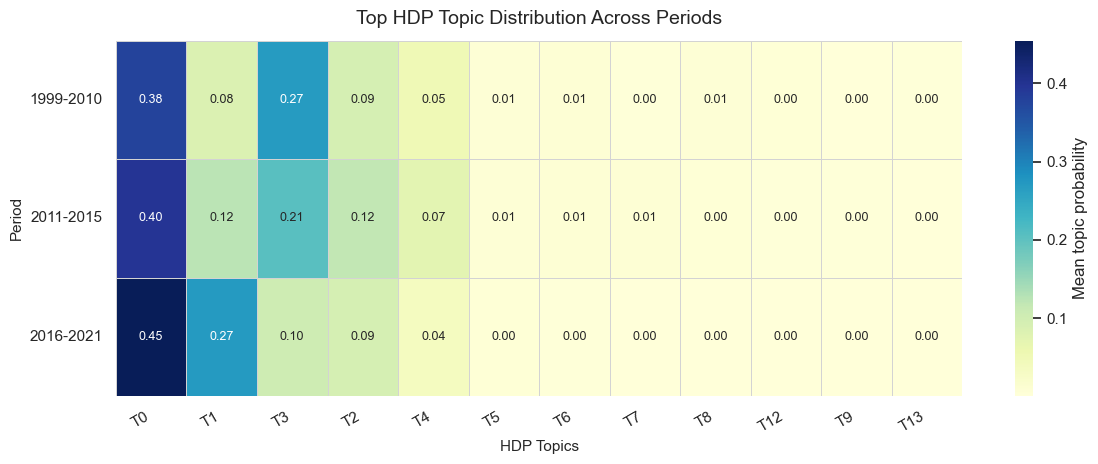

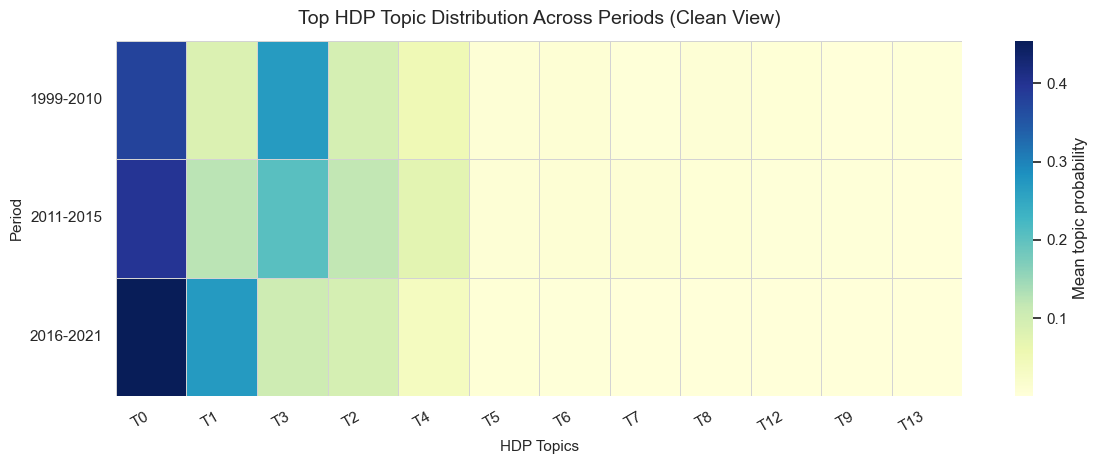


=== HDP Period Distance Matrix ===
              1999-2010     2011-2015     2016-2021
1999-2010  1.110223e-16  1.532699e-02  1.213190e-01
2011-2015  1.532699e-02  1.110223e-16  6.225305e-02
2016-2021  1.213190e-01  6.225305e-02  3.330669e-16


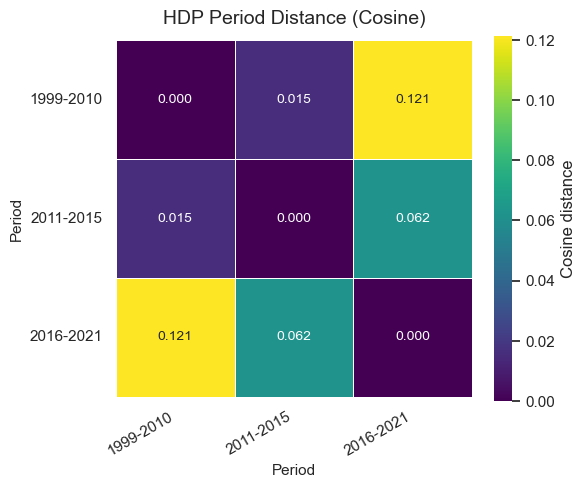

In [50]:

# HDP model
# This section applies HDP (Hierarchical Dirichlet Process) for topic modeling on the entire corpus.
# Unlike LDA, HDP does not require specifying the number of topics in advance, as it automatically
# learns an appropriate topic structure from the data.
# The code first builds a dictionary and corpus, then trains a global HDP model. After that, it extracts
# document-topic distributions and converts the sparse representations into dense vectors.
# To simplify analysis and visualization, only the globally most important topics (based on average weights)
# are retained. These topic vectors are then aggregated by period to obtain a topic profile for each time period.
# Finally, the code outputs top topics per period, visualizes them using heatmaps, and computes cosine distances
# between periods to compare how topic distributions evolve over time.
from gensim.corpora import Dictionary
from gensim.models import HdpModel
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Plot style

sns.set_theme(style="white", font_scale=1.0)


#  Prepare corpus

texts_hdp = df["tokens"].tolist()

dictionary = Dictionary(texts_hdp)
dictionary.filter_extremes(no_below=5, no_above=0.5)

corpus = [dictionary.doc2bow(text) for text in texts_hdp]

print("Number of documents:", len(corpus))
print("Vocabulary size:", len(dictionary))


# Train HDP

hdp_model = HdpModel(corpus=corpus, id2word=dictionary)

print("\n=== Sample HDP Topics ===")
for idx, topic in hdp_model.print_topics(num_topics=10, num_words=10):
    print(f"\n===== Topic {idx} =====")
    print(topic)

# Get document-topic distributions
doc_topics_hdp = [hdp_model[doc] for doc in corpus]

all_topic_ids = sorted({
    tid for doc in doc_topics_hdp for tid, _ in doc
})

print("\nNumber of used HDP topics:", len(all_topic_ids))
print("First 30 topic ids:", all_topic_ids[:30])

topic_id_to_idx = {tid: i for i, tid in enumerate(all_topic_ids)}
idx_to_topic_id = {i: tid for tid, i in topic_id_to_idx.items()}

def dense_topic_vector_hdp(topic_dist, topic_id_to_idx):
    vec = np.zeros(len(topic_id_to_idx))
    for topic_id, prob in topic_dist:
        vec[topic_id_to_idx[topic_id]] = prob
    return vec

hdp_dense = np.array([
    dense_topic_vector_hdp(topic_dist, topic_id_to_idx)
    for topic_dist in doc_topics_hdp
])

print("Dense HDP matrix shape:", hdp_dense.shape)


# Keep only globally important topics

top_n = min(12, hdp_dense.shape[1])   # 原来试了20太挤，这里改成12更适合画图

topic_means = hdp_dense.mean(axis=0)
top_idx = np.argsort(topic_means)[-top_n:]
top_idx = top_idx[np.argsort(topic_means[top_idx])[::-1]]

hdp_dense_top = hdp_dense[:, top_idx]
top_topic_ids = [idx_to_topic_id[i] for i in top_idx]

print("\nTop selected HDP topic ids:", top_topic_ids)

df["hdp_topic_vector"] = list(hdp_dense_top)


# Aggregate by period

period_hdp = {}

for period, group in df.groupby("period"):
    vecs = np.vstack(group["hdp_topic_vector"].values)
    period_hdp[period] = vecs.mean(axis=0)

period_hdp_df = pd.DataFrame(period_hdp).T

# 用更短的列名，图上更清楚
short_topic_labels = [f"T{tid}" for tid in top_topic_ids]
period_hdp_df.columns = short_topic_labels

print("\n=== Period-topic matrix ===")
print(period_hdp_df.head())


# Show top topics per period

print("\n=== Top HDP Topics Per Period ===")
for period in period_hdp_df.index:
    print(f"\n========== {period} ==========")
    top_topics = period_hdp_df.loc[period].sort_values(ascending=False).head(3)

    for col_name, score in top_topics.items():
        topic_id = int(col_name.replace("T", ""))
        print(f"\n{col_name} | weight = {score:.4f}")
        print(hdp_model.print_topic(topic_id, topn=10))


#Heatmap of top HDP topics across periods

plt.figure(figsize=(12, 4.8))

sns.heatmap(
    period_hdp_df,
    annot=True,
    fmt=".2f",                       # 原来 .3f 太密，这里改 .2f
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="lightgray",
    annot_kws={"size": 9},
    cbar_kws={"label": "Mean topic probability"}
)

plt.title("Top HDP Topic Distribution Across Periods", fontsize=14, pad=12)
plt.xlabel("HDP Topics", fontsize=11)
plt.ylabel("Period", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# cleaner heatmap without numbers

plt.figure(figsize=(12, 4.8))

sns.heatmap(
    period_hdp_df,
    annot=False,                     # 不显示数字，更适合展示整体趋势
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Mean topic probability"}
)

plt.title("Top HDP Topic Distribution Across Periods (Clean View)", fontsize=14, pad=12)
plt.xlabel("HDP Topics", fontsize=11)
plt.ylabel("Period", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# =======================
# 9. Cosine distance between periods
# =======================
sim_matrix = cosine_similarity(period_hdp_df.values)
dist_matrix = 1 - sim_matrix

dist_hdp_df = pd.DataFrame(
    dist_matrix,
    index=period_hdp_df.index,
    columns=period_hdp_df.index
)

print("\n=== HDP Period Distance Matrix ===")
print(dist_hdp_df)

plt.figure(figsize=(6, 5))

sns.heatmap(
    dist_hdp_df,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 10},
    cbar_kws={"label": "Cosine distance"}
)

plt.title("HDP Period Distance (Cosine)", fontsize=14, pad=12)
plt.xlabel("Period", fontsize=11)
plt.ylabel("Period", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# The results show that although HDP automatically learns many topics (148 topics are used),
# the high-weight topics are not well separated. The sample topics and top topics per period
# repeatedly contain very similar keywords such as network, training, neural, graph, and feature,
# suggesting considerable overlap between topics and weaker semantic boundaries than BERTopic
# or some of the LDA results. In the period-topic matrix, T0 remains dominant across all periods
# and increases further in 2016–2021; T1 becomes much stronger in the later period, while T3 decreases.
# This indicates that HDP still captures temporal change, but mainly as a redistribution of weights
# among similar topics rather than clearly differentiated semantic shifts. The cosine distance matrix
# also shows that 1999–2010 and 2011–2015 are most similar (0.015), while 2016–2021 differs more,
# especially from 1999–2010 (0.121), confirming that later topic structure changes. Overall,
# HDP has the advantage of not requiring a predefined number of topics and is useful for capturing
# broad temporal trends, but its topics are more fragmented and overlapping, making interpretation weaker
# than BERTopic and less clear than the better LDA settings. Therefore, HDP is more suitable as a
# supplementary comparison method rather than the main explanatory model.

In [51]:

# HDP separately for each period
# This section trains a separate HDP model for each time period instead of using a global model.
# The dataset is first grouped by period, and for each subset, a dictionary and corpus are built,
# followed by training an HDP model. For each period, document-topic distributions are extracted,
# and the average weight of each topic is computed to identify the most important topics in that period.
# The models, corpora, and topic distributions are stored for further analysis and comparison.
# Finally, the top topics from each period are summarized into a table to compare topic structures across time.

from gensim.corpora import Dictionary
from gensim.models import HdpModel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

# 0. Check periods

print(df["period"].value_counts())


# 1. Containers

period_hdp_models = {}
period_hdp_dictionaries = {}
period_hdp_corpora = {}
period_hdp_doc_topics = {}
period_hdp_topic_summary = {}


# 2. Train one HDP per period

for period, group in df.groupby("period"):
    print(f"\n==============================")
    print(f"Training HDP for period: {period}")
    print(f"Number of documents: {len(group)}")
    print(f"==============================")
    
    texts_period = group["tokens"].tolist()
    
    # Build dictionary
    dictionary = Dictionary(texts_period)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    
    # Build corpus
    corpus = [dictionary.doc2bow(text) for text in texts_period]
    
    print("Vocabulary size:", len(dictionary))
    
    # Train HDP
    hdp_model = HdpModel(corpus=corpus, id2word=dictionary)
    # alpha=0.01,gamma=0.01可做对比试验
    
    
    # Save objects
    period_hdp_models[period] = hdp_model
    period_hdp_dictionaries[period] = dictionary
    period_hdp_corpora[period] = corpus
    
    # Document-topic distributions
    doc_topics = [hdp_model[doc] for doc in corpus]
    period_hdp_doc_topics[period] = doc_topics
    
    # Print sample topics
    print(f"\n=== Sample topics for {period} ===")
    for idx, topic in hdp_model.print_topics(num_topics=10, num_words=10):
        print(f"\n----- Topic {idx} -----")
        print(topic)


# 3. Show top topics per period

print("\n\n==============================")
print("Top HDP topics in each period")
print("==============================")

for period, hdp_model in period_hdp_models.items():
    doc_topics = period_hdp_doc_topics[period]
    
    # collect all topic ids used in this period
    all_topic_ids = sorted({
        tid for doc in doc_topics for tid, _ in doc
    })
    
    # average topic weights over all documents in this period
    topic_avg = {}
    for tid in all_topic_ids:
        vals = []
        for doc in doc_topics:
            score = 0.0
            for topic_id, prob in doc:
                if topic_id == tid:
                    score = prob
                    break
            vals.append(score)
        topic_avg[tid] = np.mean(vals)
    
    # sort top topics
    top_topics = sorted(topic_avg.items(), key=lambda x: x[1], reverse=True)[:5]
    period_hdp_topic_summary[period] = top_topics
    
    print(f"\n========== {period} ==========")
    for tid, score in top_topics:
        print(f"\nTopic {tid} | mean weight = {score:.4f}")
        print(hdp_model.print_topic(tid, topn=10))


# 4.summary table
summary_rows = []

for period, top_topics in period_hdp_topic_summary.items():
    for rank, (tid, score) in enumerate(top_topics, start=1):
        words = period_hdp_models[period].print_topic(tid, topn=10)
        summary_rows.append({
            "period": period,
            "rank": rank,
            "topic_id": tid,
            "mean_weight": score,
            "topic_words": words
        })

summary_df = pd.DataFrame(summary_rows)

print("\n=== Summary table ===")
print(summary_df)
#This summary table lists the top 5 topics for each period, ranked by their mean weight,
# where mean_weight represents the average contribution of a topic across all documents in that period.
#
# The results reveal a clear temporal evolution pattern:
# (1) 1999–2010:
#     Topic weights are low (around 0.01–0.03) and evenly distributed,
#     indicating a fragmented research landscape with no dominant theme.
#
# (2) 2011–2015:
#     A dominant topic emerges (Topic 0 ≈ 0.25), much higher than others,
#     suggesting the formation of stronger research trends (e.g., prediction/classification),
#     while multiple topics still coexist.
#
# (3) 2016–2021:
#     Topic distribution becomes highly concentrated, with Topic 0 (≈ 0.65)
#     and Topic 1 (≈ 0.25) dominating almost entirely, and all other topics
#     having very small weights (< 0.02).
#     This reflects a strong convergence of research focus toward neural/deep/graph-based methods.
#
# Overall:
#     The topic structure evolves from "diverse → moderately focused → highly concentrated",
#     showing the shift toward deep learning dominance.
#     However, this also suggests that HDP tends to merge similar topics in later periods,
#     resulting in overlapping topics and reduced interpretability.

period
2016-2021    5743
2011-2015    1028
1999-2010     244
Name: count, dtype: int64

Training HDP for period: 1999-2010
Number of documents: 244
Vocabulary size: 670

=== Sample topics for 1999-2010 ===

----- Topic 0 -----
0.013*expert + 0.012*evaluation + 0.011*selection + 0.010*interpretation + 0.009*mean + 0.007*time + 0.007*naive + 0.007*applicable + 0.007*question + 0.006*structured

----- Topic 1 -----
0.010*address + 0.010*group + 0.009*tree + 0.009*arbitrary + 0.007*artificial + 0.007*equation + 0.007*application + 0.006*environment + 0.006*easily + 0.006*better

----- Topic 2 -----
0.007*weak + 0.007*sequence + 0.007*rule + 0.007*depend + 0.007*modeling + 0.006*general + 0.006*providing + 0.006*gradient + 0.006*classical + 0.006*approximate

----- Topic 3 -----
0.010*priori + 0.009*horizon + 0.008*confidence + 0.007*rate + 0.006*dataset + 0.006*competitive + 0.006*normal + 0.006*adapted + 0.006*generalization + 0.006*factorization

----- Topic 4 -----
0.011*common + 0.009*

In [ ]:
# The results show that training HDP separately for each period reveals clearer differences across time,
# but topic quality is not fully stable. In the early period (1999–2010), both the sample size and vocabulary
# are small, so the top topics have relatively low and scattered weights, with fragmented keywords such as
# computational, matrix, distribution, classification, and expert, indicating weaker topic concentration
# and lower interpretability. In the middle period (2011–2015), more coherent dominant themes begin to appear,
# including prediction, classification, inference, feature, and optimization, suggesting a more stable topic structure.
# In the later period (2016–2021), topic concentration becomes very strong: Topic 0 and Topic 1 have mean weights
# of 0.654 and 0.245, much larger than the remaining topics, and their keywords are highly repetitive,
# centered around network, training, neural, graph, and deep. This indicates that HDP assigns much of the later corpus
# to a few closely related topics, reflecting the dominance of deep learning-related research in the later period,
# but also showing overlap and limited separation between topics. Overall, period-specific HDP captures the trend of
# “early dispersion – middle transition – later concentration” and shows the shift toward neural / graph / deep topics,
# but compared with BERTopic and the better LDA settings, its topic boundaries remain less clear and more overlapping.
# Therefore, it is better used as a supplementary comparison method rather than the main explanatory model.